<a href="https://colab.research.google.com/github/Kl51Chris/Personal-CodeBase-Control-Robotics-and-etc/blob/main/ECE821/rocket_lander_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECE 821 Optimal Control Project 2026
1111



## Introduction

Vertical Takeoff, Vertical Landing (VTVL) is a form of takeoff and landing for rockets which can allow for reusability. Perhaps the most widely known and successful reusable VTVL vehicle is [SpaceX's Falcon 9](https://www.spacex.com/vehicles/falcon-9) first stage. Reusable rocket technology has been studied extensively in the last two decades, thanks to its many advantages over non-reusable flight systems. These include drastically lowered launch costs, rapid reusability, and reducing the environmental impacts associated with manufacturing.

In this project, you will simulate the final phase of a VTVL misson profile, which is the vertical landing phase. A [Gymnasium](https://gymnasium.farama.org) environment has been developed which simulates the simplified 2D dynamics of a VTVL rocket using the [Box2D](https://box2d.org) physics engine.

The goal of this project is to work in this environment and to develop controllers which are able to guide the descent of the rocket and bring it safely to the landing spot.

<font color='red'>NOTE</font>: We would advise you to run your code in this Colab notebook, which contains the specifications of the control problem, the linearized matrices of the rocket, and the simulator with a basic PID controller already implemented and working. This will help to avoid any compatibility issues across different systems, which we may not be able to help resolve.

## Rocket Dynamics, State, and Action Spaces


A free body diagram illustrating the forces acting on the simplified 2D rocket is shown below. Note that we do not consider air resistance or aerodynamic effects in the 2D model, for simplicity.


<img src="https://gitlab.ethz.ch/bsaverio/coco-project/-/raw/main/images/Rocket_Dynamics.png" width=400/>

### Actions
Three inputs are available for steering the rocket:
- $F_E$: the thrust produced by the main engine in Newtons (N), acting directly on the rocket body at the point where the nozzle pivots;
- $F_S$: the thrust produced by the side gas thrusters in Newtons (N), defined as the difference $F_L - F_R$, acting at a distance $l_2$ from the rocket center of mass;
- $\phi$: the angle of the nozzle with respect to the rocket body in radians (rad), which changes the direction of $F_E$. It can be discontinuous and it has instant response up to the 60 fps frame rate of our model (sampling time of the environment).

The three inputs are provided to the environment as an action:

$$\textbf{u} = \begin{bmatrix}F_E & F_S & \phi\end{bmatrix}$$

which is applied to the environment at the 60 fps frame rate. In other words, your controller must provide 60 actions per second of simulation time. These could be new actions, or the same action could be applied across multiple simulation steps.

Unlike the real world, there is no hard constraint on how long your controller has to produce a next action, although we should be able to run your code in a reasonable amount of time. In our own testing, a well performing optimization-based method took much less than 1 minute to run.

<font color='red'>IMPORTANT</font>: The controller should return *normalized* actions, as a fraction of full scale. The main engine thrust is clipped to $[0, 1]$, while the side engine thrust and nozzle angle is clipped to $[-1, 1]$. The environment then scales these to the appropriate ranges (see [*Limits on the Actuators*](#scrollTo=eb72e2bb&line=11&uniqifier=1)).


### State Variables
The state of the rocket is defined by the following variables:
- $(x, y)$: the 2D position of the rocket center of mass in meters (m);
- $(\dot{x}, \dot{y})$: the velocity of the rocket in meters per second (m/s);
- $\theta$: the angle of the rocket in radians (rad);
- $\dot{\theta}$: the angular velocity of the rocket in radians per second (rad/s);
- $c_L, c_R$: binary variables indicating whether the left or right legs are in contact with the environment, respectively (equal to 0 if no contact and 1 if contact).

The environment returns these variables as an observation:
$$\textbf{x} = \begin{bmatrix}x & y & \dot{x} & \dot{y} & \theta & \dot{\theta}& c_L & c_R\end{bmatrix}$$

The last two variables ($c_L, c_R$) may generally be ignored in your control implementation, but may be useful e.g. for turning off one or more actions once ground contact is made.

<font color='red'>IMPORTANT</font>: All variables are with respect to world frame, which is located in the *bottom-left* corner of the simulation window. The x-axis increases going right (horizontally) along the window and the y-axis increases going up (vertically). Positive angles are measured counter-clockwise from the y-axis.

## Installation

The following lines of code install the necessary packages:

In [1]:
#%%capture
# comment out the above line to display output

!apt install -y swig

%pip install --upgrade pip
%pip install poetry
%pip install 'git+https://github.com/Fireflies3072/rocket-lander.git'

# for rendering video
%pip install pyvirtualdisplay imageio-ffmpeg "moviepy>=1.0"
!sudo apt-get update
!apt-get install -y xvfb ffmpeg

# imports
import os
import random
import gymnasium as gym
import numpy as np
import coco_rocket_lander  # need to import to call gym.make()
from coco_rocket_lander.env import SystemModel
from coco_rocket_lander.algs import PID_RocketLander
import base64
import glob
import io
from IPython.display import HTML
from IPython import display as ipythondisplay
from pyvirtualdisplay import Display
from dataclasses import dataclass
from typing import Optional, Tuple
import warnings
import cvxpy as cp
from cvxpy.atoms.affine.wraps import psd_wrap
YELLOW = "\x1b[33;20m"
ENDL = "\x1b[0m"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
swig is already the newest version (4.0.2-1ubuntu1).
0 upgraded, 0 newly installed, 0 to remove and 74 not upgraded.
  Cloning https://github.com/Fireflies3072/rocket-lander.git to /tmp/pip-req-build-am2xt58i
  Running command git clone --filter=blob:none --quiet https://github.com/Fireflies3072/rocket-lander.git /tmp/pip-req-build-am2xt58i
  Resolved https://github.com/Fireflies3072/rocket-lander.git to commit 97c779596a12d3b6eee355d13c5a0b5e17e10421
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:3 https://cli.github.com/packages stable InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRe

## PID Controller

The following code initializes a basic PID controller that can be used to steer the rocket from "ideal" initial conditions of the rocket. We use the PID controller to compute the control actions in the simulation. The following code also illustrates how to interact with the simulator environment.

In [2]:
import gymnasium as gym
import numpy as np
from coco_rocket_lander.algs.pid import PID_RocketLander

args = {
}

# --- Environment Setup ---
env = gym.make("coco_rocket_lander/RocketLander-v0", render_mode="rgb_array", args=args)
env = gym.wrappers.RecordVideo(env, 'video', episode_trigger=lambda x: True, name_prefix="pid_example")

# --- Configuration ---
# PID Parameters
engine_pid_params = [10, 0, 10]
side_engine_pid_params = [5, 0, 6]
engine_vector_pid_params = [0.085, 0.001, 10.55]

# PID controller
pid = PID_RocketLander(engine_pid_params, side_engine_pid_params, engine_vector_pid_params,
                        min_output=env.action_space.low, max_output=env.action_space.high)

# Define the target state for the rocket
# Target: land at the landing position with zero velocity and angle
landing_position = env.unwrapped.get_landing_position()
target = np.zeros(6, dtype=np.float64)
target[0] = landing_position[0]
target[1] = landing_position[1]

# Reset the environment
state, _ = env.reset(seed=0)

for i in range(2000):
    action = pid.update(state[:6], target)
    if i == 0:
        print("raw action:", action)
        print("type(action):", type(action))
        print("np.asarray(action).shape:", np.asarray(action).shape)
        print("np.asarray(action).dtype:", np.asarray(action).dtype)
        print("action_space.contains(action):", env.action_space.contains(np.asarray(action, dtype=env.action_space.dtype)))
    # If the legs are in contact, set both main and side engine thrusts to 0
    if state[6] and state[7]:
        action[:] = 0

    # Apply the calculated action to the environment
    next_state, rewards, done, _, info = env.step(action)

    # Update observation
    state = next_state

    # Check if simulation ended
    if done:
        break

print("Control phase finished.")
env.close()


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /content/video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


raw action: [ 0.00000000e+00 -4.98861913e-03 -5.45540685e-05]
type(action): <class 'numpy.ndarray'>
np.asarray(action).shape: (3,)
np.asarray(action).dtype: float64
action_space.contains(action): True
Control phase finished.


In [3]:
print("action_space:", env.action_space)
print("action low:", env.action_space.low)
print("action high:", env.action_space.high)

action_space: Box([ 0. -1. -1.], 1.0, (3,), float64)
action low: [ 0. -1. -1.]
action high: [1. 1. 1.]


### View the Video

The above code specifies to save the video in a folder called `video`. We can open this folder to look at the recorded episode as follows. First, we define a `show_video` method for convenience:


In [4]:
# set up `show_video` function for Google Colab

# create a display
display = Display(visible=0, size=(1400, 900))
display.start()

# play back the video
def show_video(prefix: str):
  mp4list = glob.glob('video/*.mp4')
  if len(mp4list) > 0:
    mp4list = [os.path.basename(name) for name in mp4list]
    valid_videos = [name for name in mp4list if name.startswith(prefix)]
    if len(valid_videos) == 0:
      raise FileNotFoundError(f"Did not find a video starting with '{prefix}'. Found: {mp4list}")
    if len(valid_videos) > 1:
      raise ValueError(f"Found multiple videos starting with '{prefix}', please be more specific! Found: {valid_videos}")
    mp4 = valid_videos[0]  # we should only have one
    video = io.open('video/' + mp4, 'r+b').read()
    encoded_video = base64.b64encode(video).decode('ascii')
    ipythondisplay.display(HTML(data=f'''<video alt="test" autoplay loop controls style="height: 400px;">
                         <source src="data:video/mp4;base64,{encoded_video}" type="video/mp4" />
                       </video>'''))
  else:
    print("Did not find any files ending with .mp4 in the video folder!")

Then we invoke this method to play the video with title prefix `pid_example` in the `video` folder:

In [5]:
show_video('pid_example')

## Linearized Model of the Rocket Problem

A basic linearized model of the rocket dynamics has been derived and is provided to you with the discrete-time update equation of the form

$$\textbf{x}_{k+1} = A \textbf{x}_{k} + B\textbf{u}_{k}.$$
<!-- $$\dot{\textbf{x}} = A \textbf{x} + B\textbf{u}$$ -->
 <!-- $$\textbf{x}_{t+1} = A \textbf{x}_{t} + B\textbf{u}_{t}.$$ -->

Note:
- This equation assumes that we have discarded the last two elements ($c_L, c_R$) of the state observation $\textbf{x}$ returned by the environment;
- The $A$ matrix has shape $\mathbb{R}^{6\times 6}$ and $x_k$, $x_{k+1}$ vectors have shape $\mathbb{R}^{6\times 1}$;
- The $B$ matrix has shape $\mathbb{R}^{6\times3}$ and $u_k$ vector has shape $\mathbb{R}^{3\times 1}$;
- We linearize around the upright equilibrium with action $\tilde{\textbf{u}} = \begin{bmatrix} mg & 0 & 0 \end{bmatrix}$

Moreover, $x$ and $A$ are unnormalized, but $u_k$ is normalized. We need to multiply a coefficient matrix with $u_k$ to get the unnormalized(actual) input.

  $$u_\text{k,unnormalized} =
  \begin{bmatrix}
    F_{E, \textrm{max}} & 0 & 0\\
    0 & F_{S, \textrm{max}} & 0\\
    0 & 0 & \phi_{\textrm{max}}
  \end{bmatrix} u_k$$

We scale $B$ such that *normalized actions* (as a fraction of full scale) satisfy the update equation. The normalization of $B$ is performed as follows:

  $$B_\text{unnormalized} u_\text{k,unnormalized} = \left(B_\text{unnormalized}
  \begin{bmatrix}
    F_{E, \textrm{max}} & 0 & 0\\
    0 & F_{S, \textrm{max}} & 0\\
    0 & 0 & \phi_{\textrm{max}}
  \end{bmatrix}\right)u_k = B u_k$$

  $$B = B_\textrm{unnormalized}
  \begin{bmatrix}
    F_{E, \textrm{max}} & 0 & 0\\
    0 & F_{S, \textrm{max}} & 0\\
    0 & 0 & \phi_{\textrm{max}}
  \end{bmatrix}$$

where $B_\textrm{unnormalized}$ is simply the usual linearized, discrete-time input matrix obtained from the system dynamics. The maximum values used for scaling are given in the following section, [*Limits on the Actuators*](#scrollTo=eb72e2bb&line=11&uniqifier=1).

The following code demonstrates how to obtain the system matrices:

In [6]:
env = gym.make("coco_rocket_lander/RocketLander-v0", render_mode="rgb_array", args={})

model = SystemModel(env)

# by default, linearize around upright equilibrium with F_E = m*g
model.calculate_linear_system_matrices()

# you are free to change the sampling time as you wish
model.discretize_system_matrices(sample_time=0.1)
A, B = model.get_discrete_linear_system_matrices()

print("A:\n", A.round(3), "\n"*2, "B:\n", B.round(3))


A:
 [[ 1.     0.     0.1    0.    -0.049 -0.002]
 [ 0.     1.     0.     0.1    0.     0.   ]
 [ 0.     0.     1.     0.    -0.981 -0.049]
 [ 0.     0.     0.     1.     0.     0.   ]
 [ 0.     0.     0.     0.     1.     0.1  ]
 [ 0.     0.     0.     0.     0.     1.   ]] 

 B:
 [[ 0.000e+00  3.000e-03 -1.300e-02]
 [ 1.520e-01  0.000e+00  0.000e+00]
 [ 0.000e+00  6.200e-02 -2.520e-01]
 [ 3.039e+00  0.000e+00  0.000e+00]
 [ 0.000e+00 -3.000e-03 -1.600e-02]
 [ 0.000e+00 -5.700e-02 -3.210e-01]]


## Specifications of the Control Problem

### Limits on the Actuators

The following limits should be assumed for the normalized actions to the enivornment:

- $F_E \in [0, 1]$;
- $F_S \in [-1, 1]$;
- $\phi \in [-1 ,1]$

That is, $\textbf{u} \in [0,1]\times [-1,1] \times [-1,1]$.

Actions outside this range will be clipped. These are then multiplied by the actual maximum thrust/angle limits to get the value which is applied to the environment. The maximum values can be queried as follows:

In [7]:
print(f"Main engine max. thrust (F_E,max): {env.unwrapped.cfg.main_engine_thrust}")
print(f"Side engine max. thrust (F_S,max): {env.unwrapped.cfg.side_engine_thrust}")
print(f"Max. absolute nozzle angle (phi_max) (in radians): {env.unwrapped.cfg.max_nozzle_angle}")

Main engine max. thrust (F_E,max): 16118.518518518518
Side engine max. thrust (F_S,max): 322.3703703703704
Max. absolute nozzle angle (phi_max) (in radians): 0.2617993877991494


The limits can also be directly queried from the environment:

In [8]:
print(f"Main engine normalized thrust limits: {env.unwrapped.cfg.main_engine_thrust_limits}")
print(f"Side engine normalized thrust limits: {env.unwrapped.cfg.side_engine_thrust_limits}")
print(f"Nozzle normalized angle limits: {env.unwrapped.cfg.nozzle_angle_limits}")

Main engine normalized thrust limits: (0.0, 1.0)
Side engine normalized thrust limits: (-1.0, 1.0)
Nozzle normalized angle limits: (-1.0, 1.0)


### Limits on the State
The following limits should be assumed for the state:

- $x \in [0, 33.333]$;
- $y \in [0, 26.666]$;
- $\theta \in [-0.6108, 0.6108]$ (i.e., $[-35°,35°]$)

These are the *maximal* limits for the simulation, and the simulation will terminate if these are exceeded. Your controller should at least consider these limits on the state space.

There are no enforced limits on the linear or angular velocity. Of course, the simulator steps forwards at 60 frames per second and there is some velocity at which the rocket will exit the allowable state space in a single timestep.

<font color='red'>IMPORTANT</font>: Note that the environment exclusively uses *radians* for angles.

These values can also be directly queried from the environment:

In [9]:
print(f"State x limits: {[0, env.unwrapped.cfg.width]}")
print(f"State y limits: {[0, env.unwrapped.cfg.height]}")
print(f"State angle limits (in radians): {[-env.unwrapped.cfg.theta_limit, env.unwrapped.cfg.theta_limit]}")

State x limits: [0, 33.333333333333336]
State y limits: [0, 26.666666666666668]
State angle limits (in radians): [-0.6108652381980153, 0.6108652381980153]


### Landing Constraints
By default, the landing barge is placed halfway across the screen and 1/8th of the way up, unless changed on initialization (see [*Arguments Provided to the Environment*](#scrollTo=eb9d6a9e) below). The landing position can be queried from the environment at runtime as:

In [10]:
landing_position = env.unwrapped.get_landing_position()  # 3-tuple (x_des, y_des, theta_des)
print(f"Landing position (x, y, theta): {landing_position}")

Landing position (x, y, theta): [np.float64(16.66666603088379), np.float64(7.4796546662204), 0.0]


Where $x_\mathrm{des}$, $y_\mathrm{des}$ and $\theta_\mathrm{des}$ is the desired 2D position and angle of the rocket such that it lands on the center of the barge.

<font color='red'>IMPORTANT</font>: For simplicity of implementation, we return the position of the rocket center of mass *above* the barge that the rocket center of mass should be at for a successful landing. We also subtract a small fudge factor of 0.15m such that the rocket legs actually trigger a contact with the barge.

#### Successful Landings

If the rocket legs make contact with the sea, or if the rocket body makes contact with anything, we immediately terminate the environment. The rocket legs may otherwise make contact with any part of the landing platform.

If both rocket legs make contact with the landing platform and the rocket stops moving, the landing will be considered successful. The environment will return `done = True`. If the environment terminates for any other reason, the environment will also return `done = True`.

### Arguments Provided to the Environment

Initialization arguments can be provided to the environment in a dictionary. We've defined several arguments which a user may provide to test different aspects of the simulation. The following is an excerpt of the relevant code:

In [11]:
@dataclass
class UserArgs:
    """User arguments for tweaking the environment"""

    initial_position: Optional[Tuple[float, ...]] = None  # 3-tuple (x, y, theta)
    initial_state: Optional[
        Tuple[float, ...]
    ] = None  # 6-tuple (x, y, x_dot, y_dot, theta, theta_dot)

    initial_barge_position: Optional[Tuple[float, ...]] = None  # 2-tuple (x, theta)

    # render crosses at the rocket center of mass and landing position
    render_landing_position: bool = True
    render_lander_center_position: bool = True

    # disturbances, which should generally be left disabled
    enable_wind: bool = False
    enable_moving_barge: bool = False

    random_initial_position: bool = False

<font color='red'>IMPORTANT</font>: The values $x$ and $y$ are provided as a fraction of the screen width and height, for simplicity. All other values $( \theta, \dot{\theta}, \dot{x}, \dot{y})$ use their normal units of rad, rad/s, and m/s, respectively.

For example, to initialize the rocket a quarter of the way across the screen, halfway up, and at an angle of 0.1 rad, the following arguments could be provided:

In [12]:
args = {
    "initial_position": (0.25, 0.5, 0.1) # (x, y, theta) x: 0(leftmost)-1(rightmost) y: 0(downmost)-1(uppermost)
}

env = gym.make("coco_rocket_lander/RocketLander-v0", render_mode="rgb_array", args=args)

### Other Useful Methods and Parameters

The following additional methods and parameters may be of some use during your implementation.

In [13]:
gravity = env.unwrapped.cfg.gravity  # fixed at -9.81
mass, inertia = env.unwrapped.get_mass_properties()
l1, l2 = env.unwrapped.get_dimensional_properties()

# normalized main engine thrust to compensate for gravity
gravity_comp_fraction = -gravity * mass / env.unwrapped.cfg.main_engine_thrust

print(f"Gravity: {gravity}")
print(f"Mass, Inertia: {mass, inertia}")
print(f"l1, l2: {l1, l2}")
print(f"Gravity compensation fraction: {gravity_comp_fraction}")

Gravity: -9.81
Mass, Inertia: (530.4058532714844, 1209.53515625)
l1, l2: (2.8466666666666667, 2.1350000000000002)
Gravity compensation fraction: 0.3228138748989386


#Code start from here

##Part I: Baseline PID controller and Failure of Example controller

### Simulation Utilities: Failure Scenario, Outcome Classification, and PID Baseline

This section defines the shared simulation utilities used throughout the notebook. These functions are used to generate the results shown in the failure-mode comparison and in the later controller demonstrations.

The failure scenario is modeled by manually specifying the rocket's initial condition. Instead of relying on the simulator's default randomized initial position, the function `make_failure_args()` creates a fixed initial state and disables random initialization. This makes the experiment reproducible and allows the same initial condition to be used when comparing the PID controller, the proposed model-based controller, and the data-driven controller.


The available failure-scenario parameters are:

- `x0`: initial horizontal position
- `y0`: initial vertical position
- `xdot0`: initial horizontal velocity
- `ydot0`: initial vertical velocity
- `theta0`: initial rocket attitude angle
- `thetadot0`: initial angular velocity

The function `_classify_outcome()` provides a consistent way to label the result of each simulation. The simulator does not always return a directly usable success/failure label, so this function combines simulator information with final-state heuristics. It checks whether the rocket lands near the platform, whether its velocity is small, whether it remains close to upright, and whether both legs are in contact when contact flags are available.

The function `run_pid_simulation()` runs the original PID-type controller provided in the notebook. It records the full state trajectory, control inputs, rewards, final state, landing position, and the classified outcome. This PID result serves as the baseline controller performance for the failure scenario.

In [14]:
import matplotlib.pyplot as plt

def make_failure_args(
    x0=0.5,
    y0=0.9,
    xdot0=0.0,
    ydot0=0.0,
    theta0=0.0,
    thetadot0=0.0,
):
    return {
        "initial_state": (
            x0,
            y0,
            xdot0,
            ydot0,
            theta0,
            thetadot0,
        ),
        "random_initial_position": False,
    }


def _classify_outcome(done, info, final_state, landing_position=None):
    """Best-effort outcome label using info + final state heuristics.

    A successful landing means:
    - near the landing target,
    - low velocity,
    - near upright attitude,
    - preferably both legs in contact if contact flags are available.
    """
    if not done:
        return "time_limit"

    # only trust informative info labels; ignore vague labels like "unknown"
    for key in ["status", "event", "termination_reason", "done_reason", "result"]:
        value = info.get(key)
        if value is not None:
            value = str(value)

            if value.lower() not in ["unknown", "none", ""]:
                return value

    x, y, xdot, ydot, theta, thetadot = final_state[:6]

    # leg contact flags exist in the 8-state observation
    if len(final_state) >= 8:
        left_leg_contact = bool(final_state[6])
        right_leg_contact = bool(final_state[7])
        both_legs_down = left_leg_contact and right_leg_contact
    else:
        both_legs_down = True

    gentle_velocity = (
        abs(xdot) < 0.25
        and abs(ydot) < 0.35
        and abs(thetadot) < 0.8
    )

    upright = abs(theta) < 0.35

    if landing_position is not None:
        x_land = float(landing_position[0])
        y_land = float(landing_position[1])

        near_platform = (
            abs(x - x_land) < 0.75
            and abs(y - y_land) < 0.75
        )
    else:
        near_platform = True

    if both_legs_down and near_platform and gentle_velocity and upright:
        return "landed_on_platform"

    if both_legs_down and gentle_velocity and upright and not near_platform:
        return "off_target_landing"

    if both_legs_down and not gentle_velocity:
        return "hard_landing_or_crash"

    if not upright:
        return "bad_attitude"

    if abs(xdot) >= 0.25 or abs(ydot) >= 0.35:
        return "high_velocity_termination"

    return "terminated_non_landing"


def run_pid_simulation(env_args=None, max_steps=600, video_prefix=None, seed=0):
    """Run one PID episode and return trajectories + summary metadata."""
    if env_args is None:
        env_args = {}

    sim_env = gym.make(
        "coco_rocket_lander/RocketLander-v0",
        render_mode="rgb_array",
        args=env_args,
    )

    if video_prefix is not None:
        sim_env = gym.wrappers.RecordVideo(
            sim_env,
            "video",
            episode_trigger=lambda x: True,
            name_prefix=video_prefix,
        )

    sim_pid = PID_RocketLander(
        engine_pid_params,
        side_engine_pid_params,
        engine_vector_pid_params,
        min_output=sim_env.action_space.low,
        max_output=sim_env.action_space.high,
    )

    state, info = sim_env.reset(seed=seed)

    landing_position = sim_env.unwrapped.get_landing_position()
    target = np.zeros(6, dtype=np.float64)
    target[0] = landing_position[0]
    target[1] = landing_position[1]

    states = [state.copy()]
    actions = []
    rewards = []
    done = False

    for _ in range(max_steps):
        action = sim_pid.update(state[:6], target)

        if state[6] and state[7]:
            action[:] = 0

        next_state, reward, terminated, truncated, step_info = sim_env.step(action)

        actions.append(action.copy())
        rewards.append(reward)
        states.append(next_state.copy())

        state = next_state
        info = step_info

        if terminated or truncated:
            done = True
            break

    sim_env.close()

    states = np.asarray(states, dtype=np.float64)
    actions = (
        np.asarray(actions, dtype=np.float64)
        if len(actions)
        else np.zeros((0, 3), dtype=np.float64)
    )
    rewards = np.asarray(rewards, dtype=np.float64)

    outcome = _classify_outcomeoutcome = _classify_outcome(
    done,
    info if isinstance(info, dict) else {},
    states[-1],
    landing_position,
)

    return {
        "states": states,
        "actions": actions,
        "rewards": rewards,
        "done": bool(done),
        "steps": len(actions),
        "final_state": states[-1],
        "info": info if isinstance(info, dict) else {},
        "outcome": outcome,
        "landing_position": landing_position,
        "env_args": env_args,
    }


PID Baseline and Failure-Scenario Simulation

This cell runs the original PID controller under two different initial conditions.

First, the baseline case uses a fixed initial state close to the simulator's nominal operating condition. Random initial positioning is disabled so that the result is reproducible.

Second, the failure scenario introduces an initial tilted descent condition. The rocket starts with a nonzero attitude angle `theta0`, and the initial velocity is aligned with this tilted body direction:

In this experiment, `v0 < 0`, so the rocket is initially descending. This creates a landing condition where the rocket has both vertical descent speed and horizontal drift induced by its tilted attitude. This is a more difficult condition for the PID controller because the translational motion and attitude are coupled.

The helper function `summarize_run()` prints a compact comparison of each simulation result, including:

- outcome label,
- termination status,
- number of simulation steps,
- final position and attitude,
- final translational and angular velocity.

These summaries are used to verify whether the controller lands successfully, crashes, or terminates with excessive velocity or poor attitude.

In [15]:
def summarize_run(name, result):
    fs = result["final_state"]
    print(f"[{name}] outcome={result['outcome']}, done={result['done']}, steps={result['steps']}")
    print(f"  final pose    : x={fs[0]:.3f}, y={fs[1]:.3f}, theta={fs[4]:.3f}")
    print(f"  final velocity: xdot={fs[2]:.3f}, ydot={fs[3]:.3f}, thetadot={fs[5]:.3f}")


baseline_result = run_pid_simulation(
    env_args={
        "initial_state": (
            0.5,
            0.9,
            0.0,
            0.0,
            0.0,
            0.0,
        ),
        "random_initial_position": False,
    },
    max_steps=600,
    video_prefix="pid_baseline",
)
## match theta with velocity
v0= -3
theta0=0.25
xdot0 = v0 * np.sin(theta0)
ydot0 = v0 * np.cos(theta0)
proposed_failure_args = make_failure_args(theta0=theta0,xdot0=xdot0,ydot0=ydot0)
failure_result = run_pid_simulation(env_args=proposed_failure_args,max_steps=600,video_prefix="pid_failure_trial",)
print("Compact summary:")
summarize_run("Baseline", baseline_result)
summarize_run("Failure scenario", failure_result)


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /content/video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Compact summary:
[Baseline] outcome=landed_on_platform, done=True, steps=338
  final pose    : x=16.614, y=7.582, theta=0.015
  final velocity: xdot=0.000, ydot=0.000, thetadot=0.000
[Failure scenario] outcome=high_velocity_termination, done=True, steps=232
  final pose    : x=10.120, y=7.351, theta=0.038
  final velocity: xdot=-2.837, ydot=-0.617, thetadot=-0.187


###Baseline PID controller performance analysis(Slide 1 )


This cell evaluates the original PID controller under a nominal fixed initial condition. The purpose is to confirm that the PID controller can complete the landing task in the standard case.
The rocket starts from

$$
[x_0,\; y_0,\; \dot{x}_0,\; \dot{y}_0,\; \theta_0,\; \dot{\theta}_0]
=
[0.5,\; 0.9,\; 0,\; 0,\; 0,\; 0],
$$

with random initialization disabled for reproducibility.

The trajectory and velocity plots show that the PID controller reaches the landing platform and reduces the final velocity to approximately zero. The attitude remains close to upright, so this run can be treated as a successful baseline landing.

The main-thrust signal shows frequent saturation, which is acceptable in this nominal case but indicates that the PID controller may have limited robustness margin under more difficult initial conditions.

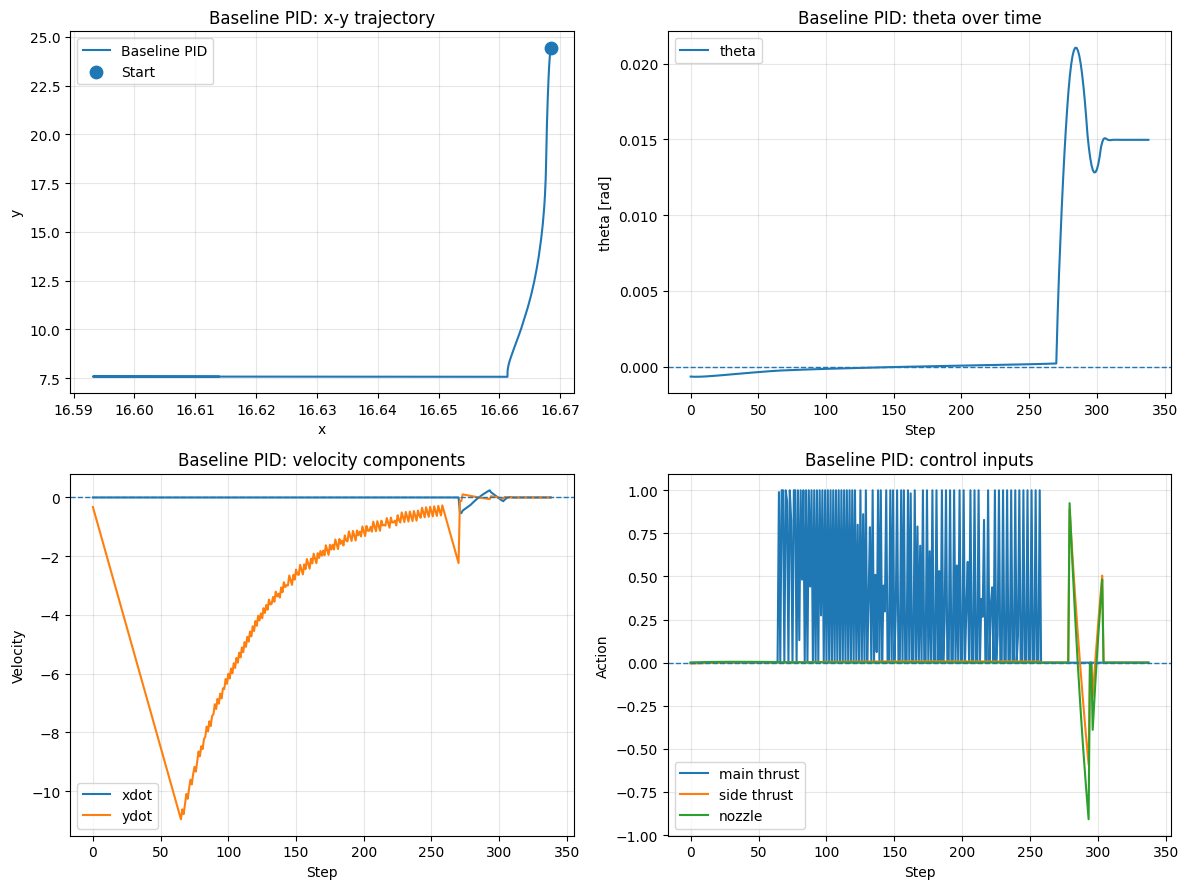

In [16]:
def plot_pid_baseline(baseline):
    states = baseline["states"]
    actions = baseline["actions"]

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    # x-y trajectory
    axes[0, 0].plot(states[:, 0], states[:, 1], label="Baseline PID")
    axes[0, 0].scatter(states[0, 0], states[0, 1], marker="o", s=80, label="Start")

    axes[0, 0].set_title("Baseline PID: x-y trajectory")
    axes[0, 0].set_xlabel("x")
    axes[0, 0].set_ylabel("y")
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # theta
    axes[0, 1].plot(states[:, 4], label="theta")
    axes[0, 1].axhline(0.0, linestyle="--", linewidth=1)
    axes[0, 1].set_title("Baseline PID: theta over time")
    axes[0, 1].set_xlabel("Step")
    axes[0, 1].set_ylabel("theta [rad]")
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # velocity
    axes[1, 0].plot(states[:, 2], label="xdot")
    axes[1, 0].plot(states[:, 3], label="ydot")
    axes[1, 0].axhline(0.0, linestyle="--", linewidth=1)
    axes[1, 0].set_title("Baseline PID: velocity components")
    axes[1, 0].set_xlabel("Step")
    axes[1, 0].set_ylabel("Velocity")
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # control inputs
    if len(actions):
        axes[1, 1].plot(actions[:, 0], label="main thrust")
        axes[1, 1].plot(actions[:, 1], label="side thrust")
        axes[1, 1].plot(actions[:, 2], label="nozzle")
    axes[1, 1].axhline(0.0, linestyle="--", linewidth=1)
    axes[1, 1].set_title("Baseline PID: control inputs")
    axes[1, 1].set_xlabel("Step")
    axes[1, 1].set_ylabel("Action")
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()
plot_pid_baseline(baseline_result)

### Failure Scenario: Tilted Descending Initial Condition

The failure scenario is created by changing only some of the initial condition while keeping the same PID controller and the same simulator environment.

Compared with the baseline case, the rocket is initialized with a nonzero attitude angle and a descending velocity aligned with that tilted direction:

$$
v_0 = -3, \qquad \theta_0 = 0.25
$$

The initial velocity components are computed as

$$
\dot{x}_0 = v_0 \sin(\theta_0), \qquad
\dot{y}_0 = v_0 \cos(\theta_0)
$$

so the failure initial condition becomes

$$
[x_0,\; y_0,\; \dot{x}_0,\; \dot{y}_0,\; \theta_0,\; \dot{\theta}_0]
=
[0.5,\; 0.9,\; v_0\sin(\theta_0),\; v_0\cos(\theta_0),\; 0.25,\; 0].
$$

Since $v_0 < 0$, the rocket is initially descending. Because $\theta_0 \neq 0$, this descent also introduces horizontal motion. The rocket begins tilted and moving downward, so the controller must correct both attitude and translational motion at the same time.

The comparison shows that the same PID controller handles the baseline case but fails under this tilted descending condition. In the failure run, the rocket drifts away from the platform and terminates before reaching a successful landing. The velocity and control-input plots show that the controller uses aggressive actuator commands, but these actions are not enough to recover the coupled position-attitude error.

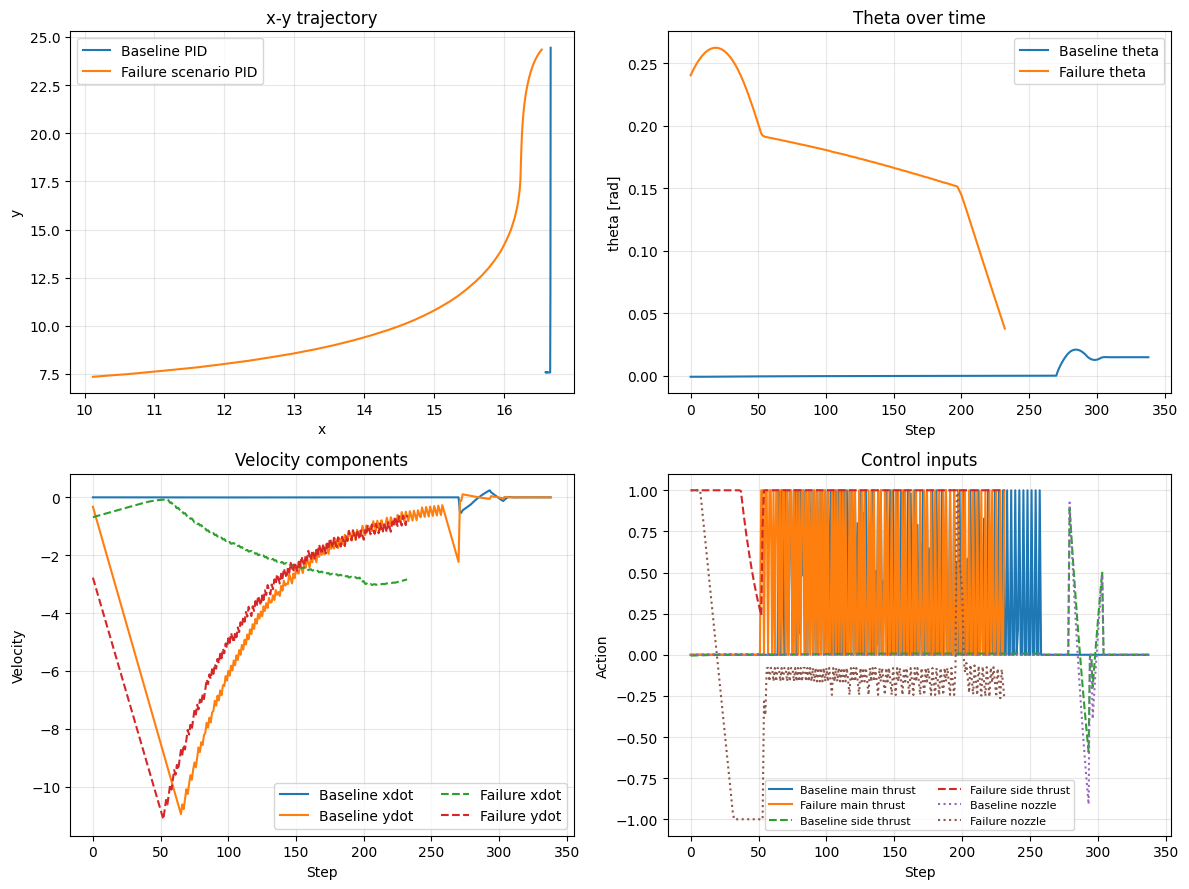

In [17]:
def plot_pid_comparison(baseline, failure):
    b_states, f_states = baseline["states"], failure["states"]
    b_actions, f_actions = baseline["actions"], failure["actions"]

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    axes[0, 0].plot(b_states[:, 0], b_states[:, 1], label="Baseline PID")
    axes[0, 0].plot(f_states[:, 0], f_states[:, 1], label="Failure scenario PID")
    axes[0, 0].set_title("x-y trajectory")
    axes[0, 0].set_xlabel("x")
    axes[0, 0].set_ylabel("y")
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(b_states[:, 4], label="Baseline theta")
    axes[0, 1].plot(f_states[:, 4], label="Failure theta")
    axes[0, 1].set_title("Theta over time")
    axes[0, 1].set_xlabel("Step")
    axes[0, 1].set_ylabel("theta [rad]")
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    axes[1, 0].plot(b_states[:, 2], label="Baseline xdot")
    axes[1, 0].plot(b_states[:, 3], label="Baseline ydot")
    axes[1, 0].plot(f_states[:, 2], '--', label="Failure xdot")
    axes[1, 0].plot(f_states[:, 3], '--', label="Failure ydot")
    axes[1, 0].set_title("Velocity components")
    axes[1, 0].set_xlabel("Step")
    axes[1, 0].set_ylabel("Velocity")
    axes[1, 0].legend(ncol=2)
    axes[1, 0].grid(True, alpha=0.3)

    if len(b_actions) and len(f_actions):
        axes[1, 1].plot(b_actions[:, 0], label="Baseline main thrust")
        axes[1, 1].plot(f_actions[:, 0], label="Failure main thrust")
        axes[1, 1].plot(b_actions[:, 1], '--', label="Baseline side thrust")
        axes[1, 1].plot(f_actions[:, 1], '--', label="Failure side thrust")
        axes[1, 1].plot(b_actions[:, 2], ':', label="Baseline nozzle")
        axes[1, 1].plot(f_actions[:, 2], ':', label="Failure nozzle")
    axes[1, 1].set_title("Control inputs")
    axes[1, 1].set_xlabel("Step")
    axes[1, 1].set_ylabel("Action")
    axes[1, 1].legend(ncol=2, fontsize=8)
    axes[1, 1].grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()


plot_pid_comparison(baseline_result, failure_result)


Baseline video

In [18]:
show_video("pid_baseline")

Failure case video

In [19]:
show_video("pid_failure_trial")

## Part II: Model Predictive Control

The previous section showed that the PID controller can fail when the rocket starts from a tilted descending initial condition. The main limitation is that PID cannot easily control coupled state. In this case, angle of main nozzle have complicated interaction with theta of the rocket, causing PID controller hard to land the rocket.
To address this limitation, we implement a linear Model Predictive Controller (MPC). MPC uses a discrete-time linear model of the rocket dynamics,

$$
x_{k+1} = A x_k + B u_k,
$$

where

$$
x_k =
\begin{bmatrix}
x_k & y_k & \dot{x}_k & \dot{y}_k & \theta_k & \dot{\theta}_k
\end{bmatrix}^T
$$

is the rocket state and

$$
u_k =
\begin{bmatrix}
u_{\text{main},k} & u_{\text{side},k} & u_{\text{nozzle},k}
\end{bmatrix}^T
$$

is the control input.

At each simulation step, the controller solves a finite-horizon optimization problem. The goal is to choose a sequence of future control inputs that keeps the predicted state close to the landing target while avoiding unnecessarily large control actions.

The MPC optimization problem is

$$
\begin{aligned}
\min_{\{x_k,u_k\}_{k=0}^{N}}
\quad
& \sum_{k=0}^{N-1}
\left[
(x_k - x_{\text{ref}})^T Q (x_k - x_{\text{ref}})
+
u_k^T R u_k
\right]
+
(x_N - x_{\text{ref}})^T Q_f (x_N - x_{\text{ref}})
\\
\text{subject to}
\quad
& x_{k+1} = A x_k + B u_k,
\\
& u_{\min} \leq u_k \leq u_{\max},
\\
& -\theta_{\max} \leq \theta_k \leq \theta_{\max},
\\
& x_0 = x_{\text{current}}.
\end{aligned}
$$

Here, $N$ is the prediction horizon. The matrix $Q$ penalizes state tracking error, $R$ penalizes control effort, and $Q_f$ penalizes the final predicted state error. The actuator limits $u_{\min}$ and $u_{\max}$ are taken directly from the simulator action space. The constraint $\theta_{\max}$ limits the attitude angle prevents rocket from having excessive tilt.

Only the first optimized control input is applied to the simulator. At the next time step, the state is measured again and the optimization problem is solved again. This receding-horizon structure allows the controller to continuously update its plan based on the current rocket state.

In [20]:
# %pip install cvxpy
import cvxpy as cp


class LinearMPCController:
    def __init__(self, A, B, horizon, Q, R, Qf, u_min, u_max, theta_max=None, solver="OSQP"):
        self.A = np.asarray(A, dtype=float)
        self.B = np.asarray(B, dtype=float)
        self.horizon = int(horizon)
        self.nx = self.A.shape[0]
        self.nu = self.B.shape[1]

        self.Q = np.asarray(Q, dtype=float)
        self.R = np.asarray(R, dtype=float)
        self.Qf = np.asarray(Qf, dtype=float)
        self.u_min = np.asarray(u_min, dtype=float)
        self.u_max = np.asarray(u_max, dtype=float)
        self.theta_max = theta_max
        self.solver = solver
        self.fallback_action = np.array([0.0, 0.0, 0.0], dtype=float)

    def update(self, state, target):
        x0 = np.asarray(state, dtype=float).reshape(-1)
        ref = np.asarray(target, dtype=float).reshape(-1)

        x = cp.Variable((self.nx, self.horizon + 1))
        u = cp.Variable((self.nu, self.horizon))

        constraints = [x[:, 0] == x0]
        objective = 0

        for k in range(self.horizon):
            dx = x[:, k] - ref
            objective += cp.quad_form(dx, self.Q) + cp.quad_form(u[:, k], self.R)
            constraints += [x[:, k + 1] == self.A @ x[:, k] + self.B @ u[:, k]]
            constraints += [u[:, k] >= self.u_min, u[:, k] <= self.u_max]
            if self.theta_max is not None:
                constraints += [x[4, k] >= -self.theta_max, x[4, k] <= self.theta_max]

        objective += cp.quad_form(x[:, self.horizon] - ref, self.Qf)
        if self.theta_max is not None:
            constraints += [x[4, self.horizon] >= -self.theta_max, x[4, self.horizon] <= self.theta_max]

        problem = cp.Problem(cp.Minimize(objective), constraints)

        try:
            problem.solve(solver=getattr(cp, self.solver), warm_start=True)
            if u.value is None:
                return self.fallback_action.copy()
            action = np.array(u.value[:, 0], dtype=float)
            return np.clip(action, self.u_min, self.u_max)
        except Exception:
            return self.fallback_action.copy()


def run_mpc_simulation(
    env_args,
    model,
    max_steps=2000,
    seed=0,
    horizon=25,
    Q=None,
    R=None,
    Qf=None,
    theta_max=0.6,
    video_prefix=None,
):
    env = gym.make("coco_rocket_lander/RocketLander-v0", render_mode="rgb_array", args=env_args)

    if video_prefix is not None:
         env = gym.wrappers.RecordVideo(env,video_folder="video",episode_trigger=lambda episode_id: True,name_prefix=video_prefix,)

    state, info = env.reset(seed=seed)
    landing_position = env.unwrapped.get_landing_position()
    ### debug check if inital position is correct
    print("env_args:", env_args)

    if isinstance(env_args, dict) and "initial_state" in env_args:
        desired = np.array(env_args["initial_state"], dtype=float)
        actual = np.array(state[:6], dtype=float)

        print("desired initial_state:", desired)
        print("actual state[:6]:     ", actual)
        print("difference:           ", actual - desired)
    #### end of debug
    target = np.array([
        landing_position[0],
        landing_position[1],
        0.0,
        0.0,
        landing_position[2],
        0.0,
    ], dtype=float)

    A, B = model.get_discrete_linear_system_matrices()
    u_min = env.action_space.low.astype(float)
    u_max = env.action_space.high.astype(float)

    if Q is None:
        Q = np.diag([10.0, 20.0, 2.0, 4.0, 30.0, 4.0])
    if R is None:
        R = np.diag([0.2, 0.2, 0.5])
    if Qf is None:
        Qf = 10.0 * Q

    print("MPC action_space:", env.action_space)
    print("MPC model shapes:", A.shape, B.shape)
    print("MPC target:", target)

    mpc = LinearMPCController(
        A=A,
        B=B,
        horizon=horizon,
        Q=Q,
        R=R,
        Qf=Qf,
        u_min=u_min,
        u_max=u_max,
        theta_max=theta_max,
        solver="OSQP",
    )

    states = [np.array(state, dtype=float)]
    actions, rewards, infos = [], [], [info]
    done = truncated = False

    first_action_logged = False

    for _ in range(max_steps):
        action = mpc.update(state[:6], target)

        if (state[6] and state[7]):
            action[:] = 0.0

        if not first_action_logged:
            print("First MPC action:", action)
            first_action_logged = True

        next_state, reward, done, truncated, info = env.step(action)

        actions.append(np.array(action, dtype=float))
        rewards.append(float(reward))
        states.append(np.array(next_state, dtype=float))
        infos.append(info)

        state = next_state
        if done or truncated:
            break

    env.close()
    #debug: check if inital condition is in there

    print("env_args:", env_args)

    states = np.array(states)
    actions = np.array(actions)
    rewards = np.array(rewards)

    result = {
        "states": states,
        "actions": actions,
        "rewards": rewards,
        "final_state": states[-1],
        "done": done,
        "truncated": truncated,
        "steps": len(actions),
        "info": info,
        "infos": infos,
        "target": target,
        "landing_position": np.array(landing_position, dtype=float),
        "controller": "Linear MPC",
        "outcome": _classify_outcome(done,info if isinstance(info, dict) else {},states[-1],landing_position,),
    }

    # optional, if infer_landing_outcome is already defined


    return result

### MPC Tuning Parameters


The MPC uses a prediction horizon of$N = 25$. \
The state-weighting matrix is $Q =\mathrm{diag}(10,\;20,\;2,\;4,\;30,\;4)$

This weighting places the largest penalties on vertical position error and attitude error, because accurate altitude control and upright orientation are most important near landing. Velocity errors are also penalized so that the rocket approaches the platform gently.

The input-weighting matrix is $R =\mathrm{diag}(0.2,\;0.2,\;0.5)$.

This penalizes excessive control effort. The nozzle input has a slightly larger penalty, which discourages aggressive attitude-control commands unless they are needed.

The terminal weight is chosen as $Q_f = 10Q$.

This makes the controller place stronger emphasis on reaching the landing target by the end of the prediction horizon.

The actuator constraints are taken directly from the simulator action space:

$$
-1 \leq u_i \leq 1,
\qquad i=1,2,3,\quad
$$

The controller also constrains the predicted attitude angle using

$$
-\theta_{\max} \leq \theta_k \leq \theta_{\max},
\qquad
\theta_{\max} = 0.6. \quad k=0,\dots,N-1.
$$

### How the Parameters Were Tuned

The parameters were tuned manually using the tilted-descending failure scenario as the main test case. I started with moderate state penalties and then increased the weights on vertical position, vertical velocity, and attitude until the rocket could recover from the initial tilt and land safely.

The attitude weight was made large because the failure case is caused by coupled attitude and translational motion. If the attitude penalty is too small, the controller may allow the rocket to remain tilted for too long, which increases horizontal drift. The vertical position and vertical velocity weights were also increased to avoid hard landings.

The input penalty $R$ was tuned after the state weights. Increasing $R$ makes the control inputs smoother but can make the controller too conservative. Decreasing $R$ makes the controller more aggressive, but it can lead to actuator saturation or noisy control behavior. The selected value keeps the MPC responsive while avoiding unnecessary control effort.

The terminal weight $Q_f = 10Q$ was chosen to make the end of the prediction horizon more important than intermediate states. This helps the controller plan toward a successful landing instead of only reducing short-term tracking error.

The attitude constraint $\theta_{\max}=0.6$ was used as a safety constraint to prevent the optimizer from planning trajectories with excessive tilt. It is more strict that actually limit is because I am afraid of wrap around of angle.

### Recommended Tuning Procedure

For a real deployment, I would recommend tuning the MPC in the following order:

1. First choose the prediction horizon $N$ based on the available computation time and the time scale of the rocket dynamics. The horizon should be long enough to capture the landing maneuver, but short enough that the optimization can be solved reliably in real time.

2. Next tune the state-weighting matrix $Q$. Start by assigning larger weights to safety-critical states such as vertical position, vertical velocity, and attitude. Then adjust the horizontal position and velocity weights to improve targeting accuracy.

3. Then tune the input-weighting matrix $R$. Increase $R$ if the controller uses overly aggressive or oscillatory inputs. Decrease $R$ if the controller is too weak to recover from disturbances.

4. After that, tune the terminal weight $Q_f$. A larger $Q_f$ encourages the controller to reach the target state by the end of the horizon, but an excessively large value may make the optimization too aggressive.


In [21]:
# Reuse existing PID failure args if present; otherwise replace placeholder below.
if "proposed_failure_args" in globals():
    mpc_failure_env_args = proposed_failure_args
    print("proposed_failure_args:")
    print(proposed_failure_args)
else:
    # Replace this with the same env_args used for the PID failure scenario.
    mpc_failure_env_args = {}

# Example run (easy to comment out if not needed):
mpc_failure_result = run_mpc_simulation(
    env_args=mpc_failure_env_args,
    model=model,
    max_steps=2000,
    seed=0,
    horizon=25,
    theta_max=0.6,
    video_prefix="mpc_failure_trial",
)



proposed_failure_args:
{'initial_state': (0.5, 0.9, np.float64(-0.7422118777635688), np.float64(-2.9067372651319343), 0.25, 0.0), 'random_initial_position': False}
env_args: {'initial_state': (0.5, 0.9, np.float64(-0.7422118777635688), np.float64(-2.9067372651319343), 0.25, 0.0), 'random_initial_position': False}
desired initial_state: [ 0.5         0.9        -0.74221188 -2.90673727  0.25        0.        ]
actual state[:6]:      [16.54079628 24.3457489  -0.68600261 -2.77796841  0.24043849  0.14716747]
difference:            [ 1.60407963e+01  2.34457489e+01  5.62092656e-02  1.28768858e-01
 -9.56150889e-03  1.47167474e-01]
MPC action_space: Box([ 0. -1. -1.], 1.0, (3,), float64)
MPC model shapes: (6, 6) (6, 3)
MPC target: [16.66666603  7.47965467  0.          0.          0.          0.        ]
First MPC action: [0. 1. 1.]


/tmp/ipykernel_179453/3159835621.py:47: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=getattr(cp, self.solver), warm_start=True)


env_args: {'initial_state': (0.5, 0.9, np.float64(-0.7422118777635688), np.float64(-2.9067372651319343), 0.25, 0.0), 'random_initial_position': False}


In [22]:
# @title
def plot_failure_comparison(pid_result, mpc_result):
    """
    Compare PID and MPC performance under the same failure scenario.
    This version improves readability when trajectories overlap.
    """

    pid_states = np.asarray(pid_result["states"])
    mpc_states = np.asarray(mpc_result["states"])

    pid_actions = np.asarray(pid_result["actions"])
    mpc_actions = np.asarray(mpc_result["actions"])

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    # helper for marker spacing
    def marker_every(arr, n_markers=12):
        if len(arr) <= n_markers:
            return 1
        return max(1, len(arr) // n_markers)

    pid_markevery = marker_every(pid_states)
    mpc_markevery = marker_every(mpc_states)

    # =========================
    # x-y trajectory
    # =========================
    ax = axes[0, 0]

    ax.plot(
        pid_states[:, 0],
        pid_states[:, 1],
        linestyle="-",
        linewidth=3.0,
        alpha=0.55,
        label="PID under failure scenario",
        zorder=2,
    )

    ax.plot(
        mpc_states[:, 0],
        mpc_states[:, 1],
        linestyle="--",
        linewidth=2.2,
        marker="o",
        markersize=4,
        markevery=mpc_markevery,
        alpha=0.95,
        label="MPC under same scenario",
        zorder=3,
    )

    # start markers
    ax.scatter(
        pid_states[0, 0],
        pid_states[0, 1],
        marker="s",
        s=70,
        label="PID start",
        zorder=5,
    )
    ax.scatter(
        mpc_states[0, 0],
        mpc_states[0, 1],
        marker="^",
        s=80,
        label="MPC start",
        zorder=6,
    )

    # end markers
    ax.scatter(
        pid_states[-1, 0],
        pid_states[-1, 1],
        marker="x",
        s=90,
        linewidths=2,
        label="PID end",
        zorder=5,
    )
    ax.scatter(
        mpc_states[-1, 0],
        mpc_states[-1, 1],
        marker="*",
        s=140,
        label="MPC end",
        zorder=6,
    )

    # small annotations
    ax.annotate(
        "PID start",
        xy=(pid_states[0, 0], pid_states[0, 1]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=8,
    )
    ax.annotate(
        "MPC start",
        xy=(mpc_states[0, 0], mpc_states[0, 1]),
        xytext=(8, -14),
        textcoords="offset points",
        fontsize=8,
    )
    ax.annotate(
        "PID end",
        xy=(pid_states[-1, 0], pid_states[-1, 1]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=8,
    )
    ax.annotate(
        "MPC end",
        xy=(mpc_states[-1, 0], mpc_states[-1, 1]),
        xytext=(8, -14),
        textcoords="offset points",
        fontsize=8,
    )

    ax.set_title("x-y trajectory")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # =========================
    # attitude over time
    # =========================
    ax = axes[0, 1]

    ax.plot(
        pid_states[:, 4],
        linestyle="-",
        linewidth=2.5,
        alpha=0.65,
        label="PID theta",
    )
    ax.plot(
        mpc_states[:, 4],
        linestyle="--",
        linewidth=2.2,
        marker="o",
        markersize=3,
        markevery=mpc_markevery,
        label="MPC theta",
    )

    ax.scatter(0, pid_states[0, 4], marker="s", s=55, zorder=5)
    ax.scatter(0, mpc_states[0, 4], marker="^", s=65, zorder=6)

    ax.set_title("Attitude over time")
    ax.set_xlabel("Step")
    ax.set_ylabel("theta [rad]")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # =========================
    # velocity components
    # =========================
    ax = axes[1, 0]

    ax.plot(
        pid_states[:, 2],
        linestyle="-",
        linewidth=2.3,
        alpha=0.65,
        label="PID xdot",
    )
    ax.plot(
        pid_states[:, 3],
        linestyle="-.",
        linewidth=2.3,
        alpha=0.65,
        label="PID ydot",
    )
    ax.plot(
        mpc_states[:, 2],
        linestyle="--",
        linewidth=2.0,
        marker="o",
        markersize=3,
        markevery=mpc_markevery,
        label="MPC xdot",
    )
    ax.plot(
        mpc_states[:, 3],
        linestyle=":",
        linewidth=2.5,
        marker="x",
        markersize=4,
        markevery=mpc_markevery,
        label="MPC ydot",
    )

    ax.set_title("Velocity components")
    ax.set_xlabel("Step")
    ax.set_ylabel("Velocity")
    ax.legend(ncol=2, fontsize=8)
    ax.grid(True, alpha=0.3)

    # =========================
    # control inputs
    # =========================
    ax = axes[1, 1]

    if len(pid_actions) > 0:
        ax.plot(
            pid_actions[:, 0],
            linestyle="-",
            linewidth=2.4,
            alpha=0.6,
            label="PID main thrust",
        )
        ax.plot(
            pid_actions[:, 1],
            linestyle="-.",
            linewidth=2.0,
            alpha=0.6,
            label="PID side thrust",
        )
        ax.plot(
            pid_actions[:, 2],
            linestyle=":",
            linewidth=2.4,
            alpha=0.6,
            label="PID nozzle",
        )

    if len(mpc_actions) > 0:
        action_markevery = marker_every(mpc_actions)

        ax.plot(
            mpc_actions[:, 0],
            linestyle="--",
            linewidth=2.0,
            marker="o",
            markersize=3,
            markevery=action_markevery,
            label="MPC main thrust",
        )
        ax.plot(
            mpc_actions[:, 1],
            linestyle="--",
            linewidth=2.0,
            marker="x",
            markersize=4,
            markevery=action_markevery,
            label="MPC side thrust",
        )
        ax.plot(
            mpc_actions[:, 2],
            linestyle=":",
            linewidth=2.8,
            marker=".",
            markersize=5,
            markevery=action_markevery,
            label="MPC nozzle",
        )

    ax.set_title("Control inputs")
    ax.set_xlabel("Step")
    ax.set_ylabel("Action")
    ax.legend(ncol=2, fontsize=8)
    ax.grid(True, alpha=0.3)

    fig.suptitle(
        "Failure Scenario: PID vs MPC",
        fontsize=14,
        fontweight="bold",
    )

    fig.tight_layout()
    plt.show()

### Result: MPC vs PID

This figure compares the original PID controller and the proposed linear MPC controller under the same tilted-descending failure scenario.

The PID controller fails to recover from the coupled attitude and velocity disturbance. Its trajectory moves away from the landing platform, and failed the landing. This shows that the PID controller has limited robustness when inital states is slightly changed.

In contrast, the MPC controller successfully lands on the platform. Instead of reacting only to the current error, it plans a sequence of actions that first reduces the attitude error and then manages the descent velocity.

From the attitude plot, the MPC controller corrects the initial tilt, where as PID failed to do so while cliped the control effort. After reducing the attitude error, the MPC controller uses the main thrust to slow the rocket and guide it toward the target. This behavior is consistent with the predictive structure of MPC: the controller can trade off short-term motion against future landing quality.

The control-input plot shows that MPC uses smoother and less saturated control actions than PID. The PID controller repeatedly reaches actuator limits, while MPC uses the actuator constraints explicitly in the optimization problem:

$$
-1 \leq u_i \leq 1.
$$

Because these constraints are included during planning, MPC avoids relying on clipped or overly aggressive control commands.

Overall, this result shows that the feasible operating region is larger for MPC than for the original PID controller. Under the same failure initial condition, PID fails while MPC lands successfully.

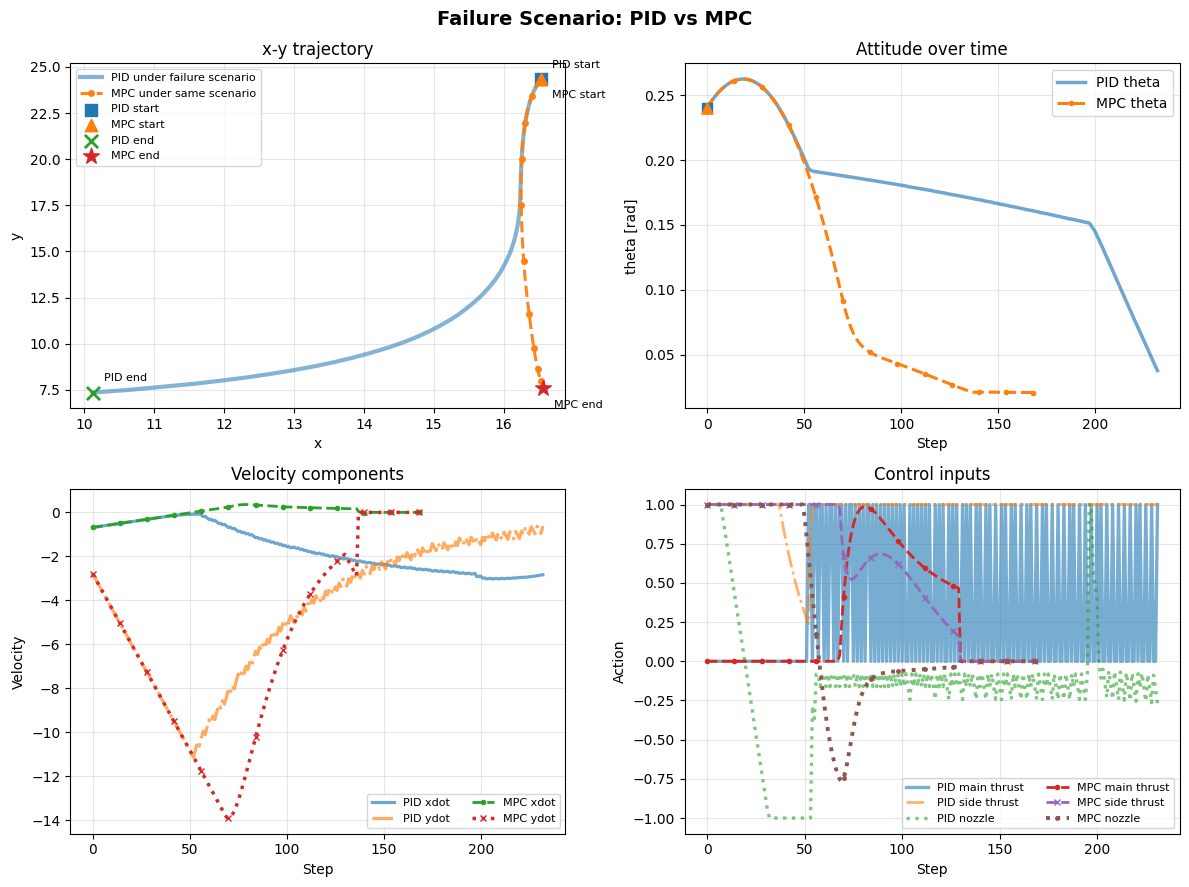

In [23]:
plot_failure_comparison(pid_result=failure_result,mpc_result=mpc_failure_result,)

Video of PID failure trail

In [24]:
show_video("pid_failure_trial")

Video of MPC success trail

In [25]:
show_video("mpc_failure_trial")

## Part III: Data-Driven Predictive Control with DeePC

In the previous section, the proposed model-based controller used the linearized dynamics model

$$
x_{k+1} = A x_k + B u_k.
$$

However, in some practical settings, an accurate model may not be available. In that case, a data-driven predictive controller can be used instead. For this part, I use Data-enabled Predictive Control, or DeePC.

DeePC is similar to MPC in that it predicts future behavior over a finite horizon and optimizes future control inputs. The main difference is that DeePC does not require an explicit state-space model. Instead of using matrices $A$ and $B$, DeePC uses previously collected input-output trajectory data to represent possible future system trajectories.

The main idea is that, for a sufficiently excited linear system, future trajectories can be represented as linear combinations of previously measured trajectories. DeePC uses Hankel matrices built from input-output data to predict future outputs and choose control inputs.

### DeePC Data Generation

The DeePC dataset is generated by running multiple simulation episodes using the original PID controller with additional random excitation. The PID controller provides a stabilizing baseline action, while the added excitation makes the collected data not overlapping and richer.
At each time step, the applied input is

$$
u_k = u_k^{\mathrm{PID}} + \epsilon_k,
$$

where $\epsilon_k$ is a small random excitation. The resulting action is clipped to satisfy the actuator limits of the simulator.

To avoid confusing the DeePC output vector with the vertical position coordinate, I denote the measured output by $z_k$:

$$
z_k =
[x_k,\; y_k,\; \dot{x}_k,\; \dot{y}_k,\; \theta_k,\; \dot{\theta}_k]^T.
$$
In the code, this sequence is stored as `Y_episodes`, but mathematically I use $z_k$ for clarity.
The input vector is

$$
u_k =
\begin{bmatrix}
u_{\mathrm{main},k} \\
u_{\mathrm{side},k} \\
u_{\mathrm{nozzle},k}
\end{bmatrix}.
$$

The data collection uses a mixture of mild and aggressive initial conditions. Each episode samples an initial attitude angle $\theta_0$ and a signed descending speed $v_0$. The initial velocity components are then computed as

$$
\dot{x}_0 = v_0 \sin(\theta_0),
\qquad
\dot{y}_0 = v_0 \cos(\theta_0).
$$

This makes the DeePC dataset cover both easier nominal-like cases and harder tilted-descent cases. This is important because the controller should be tested on the same type of failure condition where the PID controller struggled.

### Parameters Used for Data Collection

The DeePC data generation uses the following parameters:

$$
T_{\mathrm{ini}} = 5
$$

$$
N = 20
$$

$$
L = T_{\mathrm{ini}} + N = 25
$$

where $T_{\mathrm{ini}}$ is the past-history length, $N$ is the prediction horizon, and $L$ is the Hankel depth.

The input dimension is $m = 3$, corresponding to main thrust, side thrust, and nozzle input. The output dimension is $p = 6$, corresponding to position,velocity, attitude, and angular velocity.

The dataset is generated using 50 simulation episodes, with each episode limited to 250 steps. The excitation magnitude is $\text{noise scale} = 0.06$.

The probability of sampling an aggressive tilted-descent initial condition is 0.6.



### Hankel Matrix Construction

For each collected episode, the input trajectory is

$$
U =
\begin{bmatrix}
u_0 & u_1 & \cdots & u_{T-1}
\end{bmatrix},
$$

and the output trajectory is

$$
Y =
\begin{bmatrix}
z_0 & z_1 & \cdots & z_{T-1}
\end{bmatrix}.
$$

A block Hankel matrix of depth $L$ is constructed by stacking shifted windows of the trajectory. For the input data, this gives

$$
H_u =
\begin{bmatrix}
u_0 & u_1 & \cdots & u_{T-L} \\
u_1 & u_2 & \cdots & u_{T-L+1} \\
\vdots & \vdots & \ddots & \vdots \\
u_{L-1} & u_L & \cdots & u_{T-1}
\end{bmatrix}.
$$

Similarly, the output Hankel matrix is


$$
H_Y =
\begin{bmatrix}
z_0 & z_1 & \cdots & z_{T-L} \\
z_1 & z_2 & \cdots & z_{T-L+1} \\
\vdots & \vdots & \ddots & \vdots \\
z_{L-1} & z_L & \cdots & z_{T-1}
\end{bmatrix}.
$$

Since multiple episodes are collected, the Hankel matrices from all valid episodes are concatenated column-wise. This produces multi-episode Hankel matrices $H_u$ and $H_y$.

The matrices are then split into past and future blocks:

$$
H_u =
\begin{bmatrix}
U_p \\
U_f
\end{bmatrix},
\qquad
H_y =
\begin{bmatrix}
Y_p \\
Y_f
\end{bmatrix}.
$$

The past blocks contain the first $T_{\mathrm{ini}}$ steps of each Hankel column:

$$
U_p \in \mathbb{R}^{mT_{\mathrm{ini}} \times q},
\qquad
Y_p \in \mathbb{R}^{pT_{\mathrm{ini}} \times q},
$$

and the future blocks contain the next $N$ steps:

$$
U_f \in \mathbb{R}^{mN \times q},
\qquad
Y_f \in \mathbb{R}^{pN \times q}.
$$

Here, $q$ is the total number of Hankel columns collected across all valid episodes.

In the DeePC optimization, a coefficient vector $g$ is used to select a linear combination of columns from these Hankel matrices. The past data must match the most recent measured trajectory:

$$
U_p g \approx u_{\mathrm{ini}},
\qquad
Y_p g \approx y_{\mathrm{ini}}.
$$

The same coefficient vector then predicts the future input and output trajectories:

$$
u_{\mathrm{future}} = U_f g,
\qquad
y_{\mathrm{future}} = Y_f g.
$$

This is the key data-driven prediction step in DeePC. Instead of predicting future states using an explicit model, DeePC predicts future trajectories directly from measured input-output data.


In [26]:
# DeePC data-collection utilities (no optimizer here)
from collections import Counter


def extract_deepc_output(state):
    return np.asarray(state[:6], dtype=float)


def add_excitation(action, rng, noise_scale, action_low, action_high):
    action = np.asarray(action, dtype=float)
    noise = rng.uniform(-noise_scale, noise_scale, size=action.shape)
    excited = action + noise
    return np.clip(excited, action_low, action_high)


def sample_initial_args_deepc_mixture(rng, aggressive_probability=0.6):
    mild_theta_range = (-0.05, 0.10)
    mild_v0_range = (-2.5, -2.0)

    aggressive_theta_range = (0.18, 0.35)
    aggressive_v0_range = (-3.3, -2.7)

    theta_limit = 0.6108
    use_aggressive = rng.random() < aggressive_probability

    if use_aggressive:
        sweep_type = "aggressive"
        theta0 = rng.uniform(*aggressive_theta_range)
        v0 = rng.uniform(*aggressive_v0_range)
    else:
        sweep_type = "mild"
        theta0 = rng.uniform(*mild_theta_range)
        v0 = rng.uniform(*mild_v0_range)

    theta0 = float(np.clip(theta0, -theta_limit, theta_limit))
    v0 = float(v0)
    xdot0 = float(v0 * np.sin(theta0))
    ydot0 = float(v0 * np.cos(theta0))

    env_args = make_failure_args(theta0=theta0, xdot0=xdot0, ydot0=ydot0)
    meta = {
        "sweep_type": sweep_type,
        "theta0": theta0,
        "v0": v0,
        "xdot0": xdot0,
        "ydot0": ydot0,
    }
    return env_args, meta


def collect_deepc_episodes(
    env_id,
    baseline_controller_fn,
    num_episodes=50,
    max_steps_per_episode=250,
    seed=0,
    noise_scale=0.06,
    aggressive_probability=0.6,
):
    rng = np.random.default_rng(seed)
    U_episodes, Y_episodes, meta_records = [], [], []

    for ep in range(num_episodes):
        env_args, meta = sample_initial_args_deepc_mixture(
            rng, aggressive_probability=aggressive_probability
        )

        env = gym.make(env_id, render_mode="rgb_array", args=env_args)
        action_low = np.asarray(env.action_space.low, dtype=float)
        action_high = np.asarray(env.action_space.high, dtype=float)

        # allow adapters that need per-episode environment context
        if hasattr(baseline_controller_fn, "set_context"):
            baseline_controller_fn.set_context(env)

        state, _ = env.reset(seed=seed + ep)
        U_ep, Y_ep = [], []
        done = False
        truncated = False

        for _ in range(max_steps_per_episode):
            y = extract_deepc_output(state)
            baseline_action = baseline_controller_fn(state)
            action = add_excitation(
                baseline_action,
                rng=rng,
                noise_scale=noise_scale,
                action_low=action_low,
                action_high=action_high,
            )

            next_state, reward, done, truncated, info = env.step(action)
            U_ep.append(np.asarray(action, dtype=float))
            Y_ep.append(y)
            state = next_state

            if done or truncated:
                break

        env.close()

        U_ep = np.asarray(U_ep, dtype=float)
        Y_ep = np.asarray(Y_ep, dtype=float)
        U_episodes.append(U_ep)
        Y_episodes.append(Y_ep)

        meta_records.append(
            {
                **meta,
                "episode_length": int(len(U_ep)),
                "done": bool(done),
                "truncated": bool(truncated),
            }
        )

    return U_episodes, Y_episodes, meta_records


def block_hankel(data, depth):
    data = np.asarray(data, dtype=float)
    if data.ndim != 2:
        raise ValueError(f"data must be 2D with shape (T, dim), got {data.shape}")

    T, dim = data.shape
    if T < depth:
        raise ValueError(f"Need T >= depth, got T={T}, depth={depth}")

    cols = T - depth + 1
    return np.vstack([data[i : i + cols].T for i in range(depth)])


def build_multi_episode_hankel(U_episodes, Y_episodes, depth):
    Hu_blocks, Hy_blocks = [], []
    valid_episode_indices = []

    for idx, (U_ep, Y_ep) in enumerate(zip(U_episodes, Y_episodes)):
        if len(U_ep) < depth or len(Y_ep) < depth:
            continue
        Hu_blocks.append(block_hankel(U_ep, depth))
        Hy_blocks.append(block_hankel(Y_ep, depth))
        valid_episode_indices.append(idx)

    if not Hu_blocks:
        raise ValueError(
            "No valid episodes for Hankel construction. Increase episode length or reduce depth."
        )

    Hu = np.hstack(Hu_blocks)
    Hy = np.hstack(Hy_blocks)
    return Hu, Hy, valid_episode_indices


def split_deepc_hankel(Hu, Hy, T_ini, N_pred, m=3, p=6):
    depth = T_ini + N_pred
    if Hu.shape[0] != m * depth:
        raise ValueError(f"Hu row mismatch: expected {m*depth}, got {Hu.shape[0]}")
    if Hy.shape[0] != p * depth:
        raise ValueError(f"Hy row mismatch: expected {p*depth}, got {Hy.shape[0]}")

    Up = Hu[: m * T_ini, :]
    Uf = Hu[m * T_ini :, :]
    Yp = Hy[: p * T_ini, :]
    Yf = Hy[p * T_ini :, :]
    return Up, Uf, Yp, Yf


def check_deepc_pe(Hu, m, depth, tol=None):
    rank_Hu = np.linalg.matrix_rank(Hu, tol=tol)
    required_rank = m * depth
    pe_ok = rank_Hu >= required_rank
    return {
        "Hu_shape": Hu.shape,
        "rank_Hu": int(rank_Hu),
        "required_rank": int(required_rank),
        "pe_ok": bool(pe_ok),
    }


class _PIDActionAdapter:
    def __init__(self):
        self.pid = None
        self.target = None

    def set_context(self, env):
        if "engine_pid_params" in globals() and "side_engine_pid_params" in globals() and "engine_vector_pid_params" in globals():
            e_params = engine_pid_params
            s_params = side_engine_pid_params
            v_params = engine_vector_pid_params
        else:
            e_params = [10, 0, 10]
            s_params = [5, 0, 6]
            v_params = [0.085, 0.001, 10.55]

        self.pid = PID_RocketLander(
            e_params,
            s_params,
            v_params,
            min_output=env.action_space.low,
            max_output=env.action_space.high,
        )

        landing_position = env.unwrapped.get_landing_position()
        self.target = np.array([landing_position[0], landing_position[1], 0.0, 0.0, landing_position[2], 0.0], dtype=float)

    def __call__(self, state):
        if self.pid is None or self.target is None:
            raise RuntimeError("PID adapter context is not initialized. Call set_context(env) first.")
        return np.asarray(self.pid.update(state[:6], self.target), dtype=float)


pid_action_fn = _PIDActionAdapter()


In [27]:
T_ini = 5
N_pred = 20
hankel_depth = T_ini + N_pred

U_episodes, Y_episodes, deepc_meta = collect_deepc_episodes(
    env_id="coco_rocket_lander/RocketLander-v0",
    baseline_controller_fn=pid_action_fn,
    num_episodes=50,
    max_steps_per_episode=250,
    seed=0,
    noise_scale=0.06,
    aggressive_probability=0.6,
)

Hu, Hy, valid_episode_indices = build_multi_episode_hankel(
    U_episodes,
    Y_episodes,
    depth=hankel_depth,
)

Up, Uf, Yp, Yf = split_deepc_hankel(
    Hu, Hy,
    T_ini=T_ini,
    N_pred=N_pred,
    m=3,
    p=6,
)

pe_report = check_deepc_pe(Hu, m=3, depth=hankel_depth)

lengths = np.array([len(u) for u in U_episodes], dtype=int)
sweep_counts = Counter([m["sweep_type"] for m in deepc_meta])

print("Collected episodes:", len(U_episodes))
print("Valid episodes for Hankel:", len(valid_episode_indices))
print("Episode length (min/median/max):", int(lengths.min()), float(np.median(lengths)), int(lengths.max()))
print("Sweep counts:", dict(sweep_counts))
print("Example U episode shape:", U_episodes[0].shape if U_episodes else None)
print("Example Y episode shape:", Y_episodes[0].shape if Y_episodes else None)
print("Hu shape:", Hu.shape)
print("Hy shape:", Hy.shape)
print("Up shape:", Up.shape, "Uf shape:", Uf.shape)
print("Yp shape:", Yp.shape, "Yf shape:", Yf.shape)
print("rank(Hu):", pe_report["rank_Hu"])
print("required rank:", pe_report["required_rank"])
print("PE ok:", pe_report["pe_ok"])

try:
    import pandas as pd
    deepc_meta_df = pd.DataFrame(deepc_meta)
    display(deepc_meta_df.head())
    display(deepc_meta_df["sweep_type"].value_counts())
except Exception as e:
    print("pandas not available or display failed:", e)

if not pe_report["pe_ok"]:
    print("PE not satisfied. Suggestions:")
    print("- increase num_episodes")
    print("- increase noise_scale moderately")
    print("- reduce N_pred")
    print("- check whether PID + excitation is saturating too often")


Collected episodes: 50
Valid episodes for Hankel: 50
Episode length (min/median/max): 196 250.0 250
Sweep counts: {'mild': 19, 'aggressive': 31}
Example U episode shape: (250, 3)
Example Y episode shape: (250, 6)
Hu shape: (75, 10771)
Hy shape: (150, 10771)
Up shape: (15, 10771) Uf shape: (60, 10771)
Yp shape: (30, 10771) Yf shape: (120, 10771)
rank(Hu): 75
required rank: 75
PE ok: True
pandas not available or display failed: 'Display' object is not callable


#### Persistent Excitation Check

After constructing the Hankel matrix, the input Hankel matrix is checked for sufficient rank:

$$
\mathrm{rank}(H_u) \geq mL.
$$

With the selected parameters,

$$
mL = 3 \times 25 = 75.
$$

This rank condition is used as a practical check that the input data is sufficiently rich for DeePC. If the condition is not satisfied, the dataset may not contain enough excitation to represent the range of trajectories needed by the controller.


In [28]:
###singular value check
def inspect_hankel_singular_values(Hu):
    s = np.linalg.svd(Hu, compute_uv=False)

    print("===== Hu singular values =====")
    print("largest singular value:", s[0])
    print("smallest singular value:", s[-1])
    print("condition number:", s[0] / s[-1])
    print("last 10 singular values:")
    print(s[-10:])

    return s

s_Hu = inspect_hankel_singular_values(Hu)

===== Hu singular values =====
largest singular value: 432.6879147278842
smallest singular value: 3.055843324895562
condition number: 141.59361875749045
last 10 singular values:
[3.30580555 3.27979038 3.2406209  3.23873442 3.19207829 3.17725574
 3.14826701 3.11285274 3.07349268 3.05584332]


I also checked the singular values of $H_U$ as a numerical robustness check. The smallest singular value is approximately $3.06$, and the condition number is approximately $141.59$. Since the smallest singular values are not close to zero, the rank condition appears numerically reliable rather than being an artifact of floating-point noise.

In [29]:
##check excitation on all three state
def summarize_input_coverage(U_episodes):
    U_all = np.vstack(U_episodes)

    print("===== Input coverage =====")
    print("U_all shape:", U_all.shape)
    print("mean:", np.mean(U_all, axis=0))
    print("std:", np.std(U_all, axis=0))
    print("min:", np.min(U_all, axis=0))
    print("max:", np.max(U_all, axis=0))

    corr = np.corrcoef(U_all.T)
    print("input correlation matrix:")
    print(corr)

    return U_all, corr

U_all, U_corr = summarize_input_coverage(U_episodes)

===== Input coverage =====
U_all shape: (11971, 3)
mean: [ 0.33590998  0.60773318 -0.09382029]
std: [0.45324992 0.46839904 0.35765942]
min: [ 0.         -0.56337122 -1.        ]
max: [1. 1. 1.]
input correlation matrix:
[[ 1.          0.01396789 -0.03400856]
 [ 0.01396789  1.         -0.10814574]
 [-0.03400856 -0.10814574  1.        ]]


As an additional data-quality check, I inspected the coverage of the collected input data. The combined input dataset has shape $U_{\mathrm{all}} \in \mathbb{R}^{11971 \times 3}$, covering the three actuator channels.

The empirical standard deviations are$[0.453,\;0.468,\;0.358]$,

so all three input channels show meaningful variation. The observed ranges are approximately$[0,\;-0.563,\;-1]
\leq
u
\leq
[1,\;1,\;1].
$

The input correlation matrix has small off-diagonal terms, with the largest magnitude approximately $0.108$. This suggests that the input channels are not strongly correlated, so the collected data provides useful independent excitation for the DeePC Hankel construction.

In [32]:
def deepc_rollout_fit_predict(
    Up, Yp, Uf, Yf,
    u_ini, y_ini,
    lambda_g=1e-6,
):
    """
    Fit g from past input/output and predict future U/Y.
    Uses ridge-regularized least squares.
    """
    A = np.vstack([Up, Yp])
    b = np.concatenate([u_ini, y_ini])

    # solve min ||A g - b||^2 + lambda_g ||g||^2
    num_cols = A.shape[1]
    lhs = A.T @ A + lambda_g * np.eye(num_cols)
    rhs = A.T @ b

    g = np.linalg.solve(lhs, rhs)

    u_pred = Uf @ g
    y_pred = Yf @ g

    fit_error = np.linalg.norm(A @ g - b) / (np.linalg.norm(b) + 1e-8)

    return u_pred, y_pred, fit_error


def test_deepc_prediction_on_episode(
    U_ep, Y_ep,
    Up, Yp, Uf, Yf,
    T_ini,
    N_pred,
    m=3,
    p=6,
    start_idx=20,
    lambda_g=1e-6,
):
    """
    Use one episode segment as a held-out sanity check.
    """
    end_ini = start_idx + T_ini
    end_future = end_ini + N_pred

    if end_future > len(U_ep):
        raise ValueError("Episode too short for this start_idx.")

    u_ini = U_ep[start_idx:end_ini].reshape(-1)
    y_ini = Y_ep[start_idx:end_ini].reshape(-1)

    true_u_future = U_ep[end_ini:end_future].reshape(-1)
    true_y_future = Y_ep[end_ini:end_future].reshape(-1)

    u_pred, y_pred, fit_error = deepc_rollout_fit_predict(
        Up, Yp, Uf, Yf,
        u_ini,
        y_ini,
        lambda_g=lambda_g,
    )

    y_rmse = np.sqrt(np.mean((y_pred - true_y_future) ** 2))
    u_rmse = np.sqrt(np.mean((u_pred - true_u_future) ** 2))

    print("===== DeePC prediction sanity check =====")
    print("past fit relative error:", fit_error)
    print("future y RMSE:", y_rmse)
    print("future u RMSE:", u_rmse)

    return {
        "fit_error": fit_error,
        "y_rmse": y_rmse,
        "u_rmse": u_rmse,
        "u_pred": u_pred.reshape(N_pred, m),
        "y_pred": y_pred.reshape(N_pred, p),
        "true_u": true_u_future.reshape(N_pred, m),
        "true_y": true_y_future.reshape(N_pred, p),
    }


In [33]:
pred_test = test_deepc_prediction_on_episode(
    U_episodes[0],
    Y_episodes[0],
    Up, Yp, Uf, Yf,
    T_ini=T_ini,
    N_pred=N_pred,
    m=3,
    p=6,
    start_idx=20,
    lambda_g=1e-4,
)

===== DeePC prediction sanity check =====
past fit relative error: 1.8475944359525546e-07
future y RMSE: 0.10712417908368371
future u RMSE: 0.0799328208937568


In [34]:
train_count = 45

U_train_eps = U_episodes[:train_count]
Y_train_eps = Y_episodes[:train_count]

U_val_eps = U_episodes[train_count:]
Y_val_eps = Y_episodes[train_count:]

Hu_train, Hy_train, valid_train_idx = build_multi_episode_hankel(
    U_train_eps,
    Y_train_eps,
    depth=hankel_depth,
)

Up_train, Uf_train, Yp_train, Yf_train = split_deepc_hankel(
    Hu_train,
    Hy_train,
    T_ini=T_ini,
    N_pred=N_pred,
    m=3,
    p=6,
)

pe_train = check_deepc_pe(Hu_train, m=3, depth=hankel_depth)
print("Train PE report:", pe_train)

val_results = []

for i, (U_ep, Y_ep) in enumerate(zip(U_val_eps, Y_val_eps)):
    if len(U_ep) < T_ini + N_pred + 20:
        continue

    result = test_deepc_prediction_on_episode(
        U_ep,
        Y_ep,
        Up_train,
        Yp_train,
        Uf_train,
        Yf_train,
        T_ini=T_ini,
        N_pred=N_pred,
        m=3,
        p=6,
        start_idx=20,
        lambda_g=1e-4,
    )

    val_results.append(result)

y_rmses = [r["y_rmse"] for r in val_results]
u_rmses = [r["u_rmse"] for r in val_results]
fit_errors = [r["fit_error"] for r in val_results]

print("Held-out fit errors:", fit_errors)
print("Held-out y RMSEs:", y_rmses)
print("Held-out u RMSEs:", u_rmses)

print("Mean held-out fit error:", np.mean(fit_errors))
print("Mean held-out y RMSE:", np.mean(y_rmses))
print("Mean held-out u RMSE:", np.mean(u_rmses))

Train PE report: {'Hu_shape': (75, 9678), 'rank_Hu': 75, 'required_rank': 75, 'pe_ok': True}
===== DeePC prediction sanity check =====
past fit relative error: 2.2703553465991913e-07
future y RMSE: 0.2301010785231611
future u RMSE: 0.11771229183324138
===== DeePC prediction sanity check =====
past fit relative error: 9.335744433755249e-08
future y RMSE: 0.13335152005966233
future u RMSE: 0.21318876142156323
===== DeePC prediction sanity check =====
past fit relative error: 1.1136475058476406e-07
future y RMSE: 0.048235371765773444
future u RMSE: 0.2627475881476334
===== DeePC prediction sanity check =====
past fit relative error: 1.2117971258783016e-07
future y RMSE: 0.06014610248394733
future u RMSE: 0.1707166953357166
===== DeePC prediction sanity check =====
past fit relative error: 1.173293663673885e-07
future y RMSE: 0.0946615164054085
future u RMSE: 0.19402469944129333
Held-out fit errors: [np.float64(2.2703553465991913e-07), np.float64(9.335744433755249e-08), np.float64(1.113647

### DeePC Controller Implementation

After constructing the Hankel matrices from collected input-output data, DeePC is implemented as a receding-horizon predictive controller.

Once again,to avoid confusion with the vertical position coordinate $y_k$, the measured output vector is denoted by $z_k$:

$$
z_k =
[x_k,\; y_k,\; \dot{x}_k,\; \dot{y}_k,\; \theta_k,\; \dot{\theta}_k]^T.
$$

The collected output trajectory is still stored as $Y$:

$$
Y =
\begin{bmatrix}
z_0 & z_1 & \cdots & z_{T-1}
\end{bmatrix}.
$$



The DeePC optimization problem is

$$
\begin{aligned}
\min_{g,\;u_{\mathrm{future}},\;z_{\mathrm{future}}} \quad
& \sum_{k=0}^{N-1}
\left[
(z_k - z_{\mathrm{ref}})^T Q (z_k - z_{\mathrm{ref}})
+
(u_k - u_{\mathrm{ref}})^T R (u_k - u_{\mathrm{ref}})
\right]
\\
&\quad
+ \lambda_g \|g\|_2^2
+ \lambda_y \|Y_p g - z_{\mathrm{ini}}\|_2^2
\\[2mm]
\text{s.t.} \quad
\\
\begin{bmatrix}
U_p \\
U_f \\
Y_p \\
Y_f
\end{bmatrix}
g
=
\begin{bmatrix}
u_{\mathrm{ini}} \\
u_{\mathrm{future}} \\
z_{\mathrm{ini}} \\
z_{\mathrm{future}}
\end{bmatrix}
\\
& u_{\min} \leq u_k \leq u_{\max},
\qquad k = 0,\dots,N-1.
\end{aligned}
$$

Here, $Q$ penalizes output tracking error, $R$ penalizes input effort, $\lambda_g$ regularizes the Hankel coefficient vector, and $\lambda_y$ penalizes mismatch between the measured past output and the Hankel-predicted past output.

The regularization terms are important because the collected data comes from simulation rollouts with excitation noise and multiple initial conditions. Without regularization, DeePC may choose large or poorly conditioned combinations of Hankel columns, which can produce unstable or unrealistic predicted trajectories.

In [ ]:
# Cell 1: DeePC imports, output extractor, and DeePCController

def extract_deepc_output(state):
    """DeePC output y = state[:6] = [x, y, xdot, ydot, theta, thetadot]."""
    return np.asarray(state[:6], dtype=float)


class DeePCController:
    def __init__(
        self,
        Up,
        Uf,
        Yp,
        Yf,
        T_ini,
        N_pred,
        m,
        p,
        Q=None,
        R=None,
        lambda_g=1e-4,
        lambda_y=1e2,
        action_low=None,
        action_high=None,
        solver="OSQP",
        max_hankel_cols=None,
    ):
        self.T_ini = int(T_ini)
        self.N_pred = int(N_pred)
        self.m = int(m)
        self.p = int(p)
        self.lambda_g = float(lambda_g)
        self.lambda_y = float(lambda_y)
        self.solver = solver

        Up = np.asarray(Up, dtype=float)
        Uf = np.asarray(Uf, dtype=float)
        Yp = np.asarray(Yp, dtype=float)
        Yf = np.asarray(Yf, dtype=float)

        # Optional deterministic column down-selection if problem is too large
        if max_hankel_cols is not None:
            max_hankel_cols = int(max_hankel_cols)
            if Up.shape[1] > max_hankel_cols:
                idx = np.linspace(0, Up.shape[1] - 1, max_hankel_cols, dtype=int)
                Up = Up[:, idx]
                Uf = Uf[:, idx]
                Yp = Yp[:, idx]
                Yf = Yf[:, idx]

        n_cols = Up.shape[1]

        # Dimension checks
        if Up.shape != (self.m * self.T_ini, n_cols):
            raise ValueError(f"Up shape mismatch: got {Up.shape}, expected {(self.m * self.T_ini, n_cols)}")
        if Uf.shape != (self.m * self.N_pred, n_cols):
            raise ValueError(f"Uf shape mismatch: got {Uf.shape}, expected {(self.m * self.N_pred, n_cols)}")
        if Yp.shape != (self.p * self.T_ini, n_cols):
            raise ValueError(f"Yp shape mismatch: got {Yp.shape}, expected {(self.p * self.T_ini, n_cols)}")
        if Yf.shape != (self.p * self.N_pred, n_cols):
            raise ValueError(f"Yf shape mismatch: got {Yf.shape}, expected {(self.p * self.N_pred, n_cols)}")

        self.Up, self.Uf, self.Yp, self.Yf = Up, Uf, Yp, Yf
        self.num_cols = n_cols

        self.Q = np.diag([0.1, 0.1, 1.0, 1.0, 30.0, 5.0]) if Q is None else np.asarray(Q, dtype=float)
        self.R = np.diag([0.05, 0.05, 0.05]) if R is None else np.asarray(R, dtype=float)

        if self.Q.shape != (self.p, self.p):
            raise ValueError(f"Q shape mismatch: got {self.Q.shape}, expected {(self.p, self.p)}")
        if self.R.shape != (self.m, self.m):
            raise ValueError(f"R shape mismatch: got {self.R.shape}, expected {(self.m, self.m)}")

        self.action_low = (
            np.full(self.m, -np.inf, dtype=float)
            if action_low is None else np.asarray(action_low, dtype=float).reshape(self.m)
        )
        self.action_high = (
            np.full(self.m, np.inf, dtype=float)
            if action_high is None else np.asarray(action_high, dtype=float).reshape(self.m)
        )

    def solve(self, u_ini, y_ini, y_ref, u_ref=None, fallback_action=None, verbose=False):
        """
        Solve DeePC QP:
          minimize sum_k (y_k - y_ref)^T Q (y_k - y_ref) + (u_k - u_ref)^T R (u_k - u_ref)
                   + lambda_g ||g||^2 + lambda_y ||Yp g - y_ini||^2
          s.t. Up g == u_ini
               action_low <= u_k <= action_high
        """
        u_ini = np.asarray(u_ini, dtype=float).reshape(-1)
        y_ini = np.asarray(y_ini, dtype=float).reshape(-1)
        y_ref = np.asarray(y_ref, dtype=float).reshape(-1)
        if u_ref is None:
            u_ref = np.zeros(self.m, dtype=float)
        u_ref = np.asarray(u_ref, dtype=float).reshape(-1)

        if u_ini.shape != (self.m * self.T_ini,):
            raise ValueError(f"u_ini shape mismatch: got {u_ini.shape}, expected {(self.m * self.T_ini,)}")
        if y_ini.shape != (self.p * self.T_ini,):
            raise ValueError(f"y_ini shape mismatch: got {y_ini.shape}, expected {(self.p * self.T_ini,)}")
        if y_ref.shape != (self.p,):
            raise ValueError(f"y_ref shape mismatch: got {y_ref.shape}, expected {(self.p,)}")
        if u_ref.shape != (self.m,):
            raise ValueError(f"u_ref shape mismatch: got {u_ref.shape}, expected {(self.m,)}")

        g = cp.Variable(self.num_cols)

        u_future_flat = self.Uf @ g
        y_future_flat = self.Yf @ g

        objective = 0
        constraints = [self.Up @ g == u_ini]  # hard past-input fitting

        for k in range(self.N_pred):
            yk = y_future_flat[k * self.p:(k + 1) * self.p]
            uk = u_future_flat[k * self.m:(k + 1) * self.m]
            objective += cp.quad_form(yk - y_ref, self.Q)
            objective += cp.quad_form(uk - u_ref, self.R)
            constraints += [uk >= self.action_low, uk <= self.action_high]
        # attitude-braking sign constraint
        attitude_sign_constraint = "inactive"
        # diagnostic result:
        # for theta > 0 and thetadot > 0, positive side thrust reduces positive thetadot
        y_ini_window = y_ini.reshape(self.T_ini, self.p)

        theta_now = y_ini_window[-1, 4]
        thetadot_now = y_ini_window[-1, 5]

        theta_eps = 0.03
        thetadot_eps = 0.03
        K_sign = min(5, self.N_pred)

        if theta_now > theta_eps and thetadot_now > thetadot_eps:
            attitude_sign_constraint = "positive_side_required"
            for k in range(K_sign):
                uk = u_future_flat[k * self.m:(k + 1) * self.m]
                constraints += [
                    uk[1] >= 0.0,
                    uk[2] >= 0.0,
                ]

        elif theta_now < -theta_eps and thetadot_now < -thetadot_eps:
            attitude_sign_constraint = "negative_side_required"
            for k in range(K_sign):
                uk = u_future_flat[k * self.m:(k + 1) * self.m]
                constraints += [
                    uk[1] <= 0.0,
                    uk[2] <= 0.0,
                ]
        # regularization + soft past-output fitting
        objective += self.lambda_g * cp.sum_squares(g)
        objective += self.lambda_y * cp.sum_squares(self.Yp @ g - y_ini)

        prob = cp.Problem(cp.Minimize(objective), constraints)

        # Try preferred solver first, then fall back
        candidates = [self.solver, "OSQP", "ECOS", "SCS", "CLARABEL"]
        seen = set()
        candidates = [s for s in candidates if s not in seen and not seen.add(s)]

        status = None
        solver_used = None
        solved = False

        for s in candidates:
            try:
                prob.solve(solver=s, verbose=verbose, warm_start=True)
                status = prob.status
                if status in (cp.OPTIMAL, cp.OPTIMAL_INACCURATE) and g.value is not None:
                    solver_used = s
                    solved = True
                    break
            except Exception:
                continue

        if solved:
          g_val = np.asarray(g.value, dtype=float).reshape(-1)

          u_future = np.asarray((self.Uf @ g_val).reshape(self.N_pred, self.m), dtype=float)
          y_future = np.asarray((self.Yf @ g_val).reshape(self.N_pred, self.p), dtype=float)

          action = u_future[0].copy()

          # diagnostic: which Hankel columns are being used most strongly?
          abs_g = np.abs(g_val)
          top_k = min(10, g_val.size)
          top_idx = np.argsort(abs_g)[-top_k:][::-1]

          # first future input of the most-used columns
          # shape: (top_k, m)
          top_first_u = self.Uf[:self.m, top_idx].T

          # all future inputs of the most-used columns
          # shape: (N_pred, m, top_k), assuming time-major flattening
          top_future_u = self.Uf[:, top_idx].reshape(self.N_pred, self.m, top_k)

          # weighted contribution of top columns to the first action
          # each row j contributes g[j] * Uf[:m, j]
          top_first_u_contrib = (self.Uf[:self.m, top_idx] * g_val[top_idx]).T

          info = {
              "status": str(status),
              "objective_value": float(prob.value) if prob.value is not None else np.nan,
              "past_y_fit_error": float(np.linalg.norm(self.Yp @ g_val - y_ini)),
              "past_u_fit_error": float(np.linalg.norm(self.Up @ g_val - u_ini)),
              "action": action.copy(),
              "solver_used": solver_used,

              # g diagnostics
              "g_norm": float(np.linalg.norm(g_val)),
              "g_l1": float(np.sum(np.abs(g_val))),
              "g_max_abs": float(np.max(abs_g)),
              "g_nonzero_1e_4": int(np.sum(abs_g > 1e-4)),
              "g_nonzero_1e_3": int(np.sum(abs_g > 1e-3)),

              # top contributing Hankel columns
              "top_g_idx": top_idx.copy(),
              "top_g_val": g_val[top_idx].copy(),
              "top_first_u": top_first_u.copy(),
              "top_first_u_contrib": top_first_u_contrib.copy(),

              # predicted trajectories from the final g
              "pred_first_u": action.copy(),
              "pred_mean_abs_u": np.mean(np.abs(u_future), axis=0),
              "pred_max_abs_u": np.max(np.abs(u_future), axis=0),
              "pred_first_y": y_future[0].copy(),
              "pred_terminal_y": y_future[-1].copy(),
          }
          return action, info

        # Solver failure fallback
        if fallback_action is None:
            fallback_action = np.zeros(self.m, dtype=float)
        fallback_action = np.asarray(fallback_action, dtype=float).reshape(self.m)
        fallback_action = np.clip(fallback_action, self.action_low, self.action_high)

        info = {
            "status": "solver_failed",
            "objective_value": np.nan,
            "past_y_fit_error": np.nan,
            "past_u_fit_error": np.nan,
            "action": fallback_action.copy(),
            "solver_used": solver_used,
            "attitude_sign_constraint": attitude_sign_constraint,
            "theta_now": float(theta_now),
            "thetadot_now": float(thetadot_now),
        }
        return fallback_action, info

In [ ]:
# Cell 2: DeePC rollout on fixed failure scenario (PID init, then DeePC)

import gymnasium as gym


def run_deepc_on_failure(
    env_id,
    failure_args,
    deepc_controller,
    pid_action_fn,
    seed=0,
    max_steps=500,
    y_ref=None,
    u_ref=None,
    video_prefix="deepc_failure_trial",
):
    env = gym.make(env_id, render_mode="rgb_array", args=failure_args)

    env = gym.wrappers.RecordVideo(
        env,
        video_folder="video",
        episode_trigger=lambda episode_id: True,
        name_prefix=video_prefix,
    )
    action_low = np.asarray(env.action_space.low, dtype=float)
    action_high = np.asarray(env.action_space.high, dtype=float)

    states = []
    actions = []
    rewards = []
    infos = []
    controller_modes = []
    deepc_debug = []

    u_hist = []
    y_hist = []

    state, info = env.reset(seed=seed)

    # Use actual reset state (not args["initial_state"])
    if y_ref is None:
        y_ref = np.array([16.66666603088379, 7.4796546662204, 0.0, 0.0, 0.0, 0.0],dtype=float,)
    else:
        y_ref = np.asarray(y_ref, dtype=float).reshape(6,)

    done = False
    truncated = False

    for t in range(max_steps):
        # 1) PID initialization for first T_ini steps
        if t < deepc_controller.T_ini:
            mode = "PID-init"
            action = np.asarray(pid_action_fn(state), dtype=float).reshape(deepc_controller.m,)
            action = np.clip(action, action_low, action_high)

            solve_info = {
                "status": "pid_init",
                "objective_value": np.nan,
                "past_y_fit_error": np.nan,
                "past_u_fit_error": np.nan,
                "action": action.copy(),
                "solver_used": None,

            }

        # 2) DeePC control afterwards
        else:
            mode = "DeePC"

            u_ini = np.asarray(u_hist[-deepc_controller.T_ini:], dtype=float).reshape(-1)
            y_ini = np.asarray(y_hist[-deepc_controller.T_ini:], dtype=float).reshape(-1)

            pid_fallback = np.asarray(pid_action_fn(state), dtype=float).reshape(deepc_controller.m,)
            pid_fallback = np.clip(pid_fallback, action_low, action_high)

            action, solve_info = deepc_controller.solve(
                u_ini=u_ini,
                y_ini=y_ini,
                y_ref=y_ref,
                u_ref=u_ref,
                fallback_action=pid_fallback,
                verbose=False,
            )

            action = np.asarray(action, dtype=float).reshape(deepc_controller.m,)
            action = np.clip(action, action_low, action_high)
            if solve_info.get("status") == "solver_failed":
                solve_info["used_fallback"] = True
                solve_info["fallback_reason"] = "solver_failed"
                solve_info["status"] = "fallback_pid"
            else:
                solve_info["used_fallback"] = False

        # IMPORTANT alignment: store state BEFORE applying action
        states.append(np.asarray(state, dtype=float).copy())
        actions.append(action.copy())
        controller_modes.append(mode)

        # History uses current pre-step state output and applied action
        y_hist.append(extract_deepc_output(state))
        u_hist.append(action.copy())

        next_state, reward, done, truncated, info = env.step(action)

        rewards.append(float(reward))
        infos.append(info)

        if mode == "DeePC":
            deepc_debug.append(solve_info)

        state = next_state

        if done or truncated:
            break

    env.close()

    return {
        "states": np.asarray(states, dtype=float),
        "actions": np.asarray(actions, dtype=float),
        "rewards": np.asarray(rewards, dtype=float),
        "final_state": np.asarray(state, dtype=float),
        "done": bool(done),
        "truncated": bool(truncated),
        "steps": len(actions),
        "outcome": (
            info.get("outcome", "unknown")
            if isinstance(info, dict)
            else "unknown"
        ),
        "info": info if isinstance(info, dict) else {},
        "infos": infos,
        "target": np.asarray(y_ref, dtype=float),
        "controller": "DeePC",
        "controller_modes": controller_modes,
        "deepc_debug": deepc_debug,
    }

In [ ]:
# Cell 3: DeePC result summary diagnostics

from collections import Counter


def summarize_deepc_result(result):
    fs = np.asarray(result["final_state"], dtype=float)
    rewards = np.asarray(result.get("rewards", []), dtype=float)
    modes = result.get("controller_modes", [])
    dbg = result.get("deepc_debug", [])

    mode_counts = Counter(modes)
    status_counts = Counter([d.get("status", "unknown") for d in dbg])

    y_fit = np.array([d.get("past_y_fit_error", np.nan) for d in dbg], dtype=float)
    u_fit = np.array([d.get("past_u_fit_error", np.nan) for d in dbg], dtype=float)
    obj = np.array([d.get("objective_value", np.nan) for d in dbg], dtype=float)
    # print real result
    info = result.get("info", {})
    outcome = info.get("outcome", "unknown") if isinstance(info, dict) else "unknown"

    print("===== DeePC Rollout Summary =====")
    print("controller:", result.get("controller", "DeePC"))
    print("outcome:", outcome)
    print("done/truncated:", result.get("done"), "/", result.get("truncated"))
    print("steps:", result.get("steps"))
    print("final state[:6]:", fs[:6])
    print(f"final x, y, theta      : {fs[0]:.4f}, {fs[1]:.4f}, {fs[4]:.4f}")
    print(f"final xdot, ydot, thdot: {fs[2]:.4f}, {fs[3]:.4f}, {fs[5]:.4f}")
    print("total reward:", float(np.sum(rewards)) if rewards.size > 0 else np.nan)
    print("PID-init steps:", mode_counts.get("PID-init", 0))
    print("DeePC steps:", mode_counts.get("DeePC", 0))
    print("solver status counts:", dict(status_counts))
    ### print inaccurate ratio
    n_opt = status_counts.get("optimal", 0)
    n_opt_inacc = status_counts.get("optimal_inaccurate", 0)
    n_fail = status_counts.get("fallback_pid", 0) + status_counts.get("solver_failed", 0)
    n_deepc = len(dbg)
    if n_deepc > 0:
        print(f"optimal ratio: {n_opt}/{n_deepc} = {n_opt/n_deepc:.2%}")
        print(f"optimal_inaccurate ratio: {n_opt_inacc}/{n_deepc} = {n_opt_inacc/n_deepc:.2%}")
        print(f"fallback/failed ratio: {n_fail}/{n_deepc} = {n_fail/n_deepc:.2%}")
    if y_fit.size > 0:
        print("past_y_fit_error mean/max:",
              float(np.nanmean(y_fit)), float(np.nanmax(y_fit)))
    else:
        print("past_y_fit_error mean/max: n/a")

    if u_fit.size > 0:
        print("past_u_fit_error mean/max:",
              float(np.nanmean(u_fit)), float(np.nanmax(u_fit)))
    else:
        print("past_u_fit_error mean/max: n/a")

    if obj.size > 0:
        print("solve objective mean:", float(np.nanmean(obj)))
    else:
        print("solve objective mean: n/a")

### DeePC Tuning Parameters

The DeePC controller has several parameters that determine how much past data it uses, how far ahead it predicts, and how aggressively it tracks the landing target.

The past-history length is

$$
T_{\mathrm{ini}} = 5.
$$

This means that DeePC uses the most recent 5 input-output measurements to identify the current trajectory context. A longer $T_{\mathrm{ini}}$ can provide more information about the current system behavior, but it also increases the size of the Hankel matching problem.

The prediction horizon is

$$
N = 20.
$$

This horizon gives the controller enough look-ahead time to correct attitude and velocity before landing, while keeping the quadratic program small enough to solve repeatedly during simulation.

The output tracking weight is

$$
Q =
\mathrm{diag}(1.0,\; 0.1,\; 2.0,\; 0.01,\; 100.0,\; 25.0).
$$

The output vector is

$$
z_k =
[x_k,\; y_k,\; \dot{x}_k,\; \dot{y}_k,\; \theta_k,\; \dot{\theta}_k]^T.
$$

The largest weight is placed on $\theta_k$, because attitude correction is critical in the tilted-descending failure scenario. The angular velocity $\dot{\theta}_k$ is also weighted to reduce rotational motion. The velocity terms receive larger weights than the position terms, because a safe landing requires reducing speed before touchdown.

The input penalty is

$$
R =
\mathrm{diag}(5×10^{-2},\;0,\;0.05).
$$

R has no punishment on side thrust, since experiment show little effort had on side

The coefficient regularization weight is

$$
\lambda_g = 10^{-4}.
$$

This term penalizes large Hankel coefficient vectors:

$$
\lambda_g \|g\|_2^2.
$$

It helps prevent the controller from relying on extreme linear combinations of Hankel columns, which can produce unrealistic predicted trajectories.

The past-output fitting weight is

$$
\lambda_y = 10^2.
$$

This term penalizes mismatch between the measured recent output history and the Hankel-predicted past output:

$$
\lambda_y \|Y_p g - z_{\mathrm{ini}}\|_2^2.
$$

The past input is matched exactly using

$$
U_p g = u_{\mathrm{ini}},
$$

while the past output is matched softly. This is useful because the collected data contains excitation noise and comes from multiple sampled initial conditions. A soft output constraint makes the DeePC problem more robust than forcing exact output matching.

The actuator limits are inherited from the simulator:

$$
u_{\min} \leq u_k \leq u_{\max}.
$$

The solver is set to OSQP, with fallback attempts using other convex solvers if needed.

### How the DeePC Parameters Were Tuned

The DeePC parameters were tuned manually using the same tilted-descending failure scenario used to test PID and MPC.

I first selected $T_{\mathrm{ini}}=5$ so that the controller had enough recent input-output history to infer the current behavior without making the Hankel matching problem too large. Then I selected $N=20$ to give the controller enough prediction length to respond to the initial attitude and velocity error.

The output weight $Q$ was tuned by increasing the penalty on attitude $\theta$ and angular velocity $\dot{\theta}$. This was necessary because the main failure mode is caused by coupled attitude and translational motion. If the attitude weight is too small, DeePC may allow the rocket to remain tilted for too long, causing horizontal drift.

The velocity weights were also increased relative to the position weights. This encourages the controller to reduce descent speed and angular motion before reaching the platform. The position weights were kept smaller because DeePC performance was more sensitive to stabilizing attitude and velocity than to aggressively tracking position at every intermediate step.

The input weight $R$ was tuned to avoid overly aggressive actuator commands while still allowing recovery from the failure condition. A larger $R$ made the controller smoother but less responsive. A smaller $R$ made the controller more aggressive and more likely to use saturated inputs.

The regularization weight $\lambda_g$ was kept small but nonzero. This allows DeePC to use the collected data flexibly while discouraging numerically large Hankel combinations. The past-output fitting weight $\lambda_y$ was chosen to be large enough that the predicted past output stays close to the measured recent output, but not so large that the optimization becomes infeasible or overly sensitive to noise.

### Recommended Tuning Procedure

For a real deployment, I would tune DeePC in the following order.

First, collect a dataset with sufficient input excitation and verify the Hankel rank condition. DeePC tuning is only meaningful if the data is rich enough to represent the operating region of interest.

Second, choose $T_{\mathrm{ini}}$. It should be long enough to capture the recent system behavior, but not so long that the Hankel matrices become unnecessarily large or difficult to match.

Third, choose the prediction horizon $N$. The horizon should cover the important time scale of the landing maneuver. If $N$ is too short, the controller behaves too reactively. If $N$ is too long, the optimization becomes larger and may become less reliable.

Fourth, tune $Q$ based on landing priorities. For this rocket landing task, attitude, angular velocity, vertical velocity, and vertical position should be prioritized because they directly affect landing safety.

Fifth, tune $R$ to balance control smoothness and recovery ability. Increase $R$ if the controller uses noisy or overly aggressive inputs. Decrease $R$ if the controller is too weak to recover from disturbances.

Sixth, tune $\lambda_g$ and $\lambda_y$. Increase $\lambda_g$ if the controller relies on very large Hankel coefficients or produces unrealistic predictions. Increase $\lambda_y$ if the predicted past output does not match the measured history well. Decrease $\lambda_y$ if the problem becomes too rigid or solver reliability decreases.

Finally, validate the selected tuning over multiple initial conditions, not only one failure scenario. The final tuning should be judged using landing success rate, final velocity, attitude at touchdown, actuator saturation, solver status, and past-output fitting error.

In [ ]:
# Cell 4: Instantiate DeePC and run on the fixed failure scenario

# Preconditions from your notebook context:
# Up, Uf, Yp, Yf, T_ini, N_pred, m, p, pid_action_fn, proposed_failure_args already exist.

assert T_ini == 5, f"Expected T_ini=5, got {T_ini}"
assert N_pred == 20, f"Expected N_pred=10, got {N_pred}"
assert m == 3, f"Expected m=3, got {m}"
#assert p == 6, f"Expected p=6, got {p}"

env_id = "coco_rocket_lander/RocketLander-v0"

# Read full 3D action bounds from environment
env_tmp = gym.make(env_id, render_mode="rgb_array", args=proposed_failure_args)
action_low = np.asarray(env_tmp.action_space.low, dtype=float)
action_high = np.asarray(env_tmp.action_space.high, dtype=float)
env_tmp.close()

Q_deepc = np.diag([1.0, 0.1, 2.0, 0.01, 100.0, 25.0])
#R_deepc = np.diag([0.05, 0.05, 0.05])
R_deepc = np.diag([5e-2, 0, 0.05]) ## TUNE EFFort 1

deepc_controller = DeePCController(
    Up=Up,
    Uf=Uf,
    Yp=Yp,
    Yf=Yf,
    T_ini=T_ini,
    N_pred=N_pred,
    m=3,
    p=6,
    Q=Q_deepc,
    R=R_deepc,
    lambda_g=1e-2,
    lambda_y=1e2,
    action_low=action_low,
    action_high=action_high,
    solver="OSQP",
    max_hankel_cols=500,  # set None to use full columns should be 2000,but let try out
)

deepc_failure_result = run_deepc_on_failure(
    env_id=env_id,
    failure_args=proposed_failure_args,
    deepc_controller=deepc_controller,
    pid_action_fn=pid_action_fn,
    seed=0,
    max_steps=500,
    y_ref=None,           # uses actual reset state: [x0, y0, 0, 0, 0, 0]
    u_ref=np.zeros(3),    # full 3D input reference
    video_prefix="deepc_failure_trial",
)

summarize_deepc_result(deepc_failure_result)

print("\nFirst 5 DeePC debug entries:")
for item in deepc_failure_result["deepc_debug"][:5]:
    print(item)

print("\nSolver status counts:")
print(Counter([d["status"] for d in deepc_failure_result["deepc_debug"]]))

####simulation Result

In [ ]:
# @title

# ----------------------------
# 0) Resolve result variables
# ----------------------------
# Expected:
# - PID failure result: failure_result
# - MPC failure result: mpc_failure_result
# - DeePC failure result: deepc_failure_result

pid_res = globals().get("failure_result", None)
mpc_res = globals().get("mpc_failure_result", None)
deepc_res = globals().get("deepc_failure_result", None)

if pid_res is None:
    # optional alias if your notebook used different names
    pid_res = globals().get("pid_failure_result", None)
if mpc_res is None:
    mpc_res = globals().get("failure_result_mpc", None)
if deepc_res is None:
    deepc_res = globals().get("deepc_result", None)

assert pid_res is not None, "PID failure result not found (expected `failure_result` or `pid_failure_result`)."
assert mpc_res is not None, "MPC failure result not found (expected `mpc_failure_result`)."
assert deepc_res is not None, "DeePC failure result not found (expected `deepc_failure_result` or `deepc_result`)."


# ----------------------------
# 1) Pretty summary printers
# ----------------------------
def _safe_outcome(res):
    if "outcome" in res:
        return res["outcome"]
    if res.get("done", False):
        return "done"
    if res.get("truncated", False):
        return "truncated"
    return "unknown"

def print_result_summary(name, res):
    fs = np.asarray(res["final_state"], dtype=float)
    rewards = np.asarray(res.get("rewards", []), dtype=float)
    print(f"[{name}] outcome={_safe_outcome(res)}, done={res.get('done')}, truncated={res.get('truncated')}, steps={res.get('steps')}")
    print(f"  final pose    : x={fs[0]:.4f}, y={fs[1]:.4f}, theta={fs[4]:.4f}")
    print(f"  final velocity: xdot={fs[2]:.4f}, ydot={fs[3]:.4f}, thetadot={fs[5]:.4f}")
    print(f"  total reward  : {float(np.sum(rewards)) if rewards.size else np.nan:.4f}")

print("===== Controller summaries =====")
print_result_summary("PID failure", pid_res)
print_result_summary("MPC failure", mpc_res)
print_result_summary("DeePC failure", deepc_res)

# DeePC-specific debug stats
dbg = deepc_res.get("deepc_debug", [])
if len(dbg) > 0:
  status_counts = Counter([d.get("status", "unknown") for d in dbg])
  mode_counts = Counter(deepc_res.get("controller_modes", []))

  y_fit = np.array([d.get("past_y_fit_error", np.nan) for d in dbg], dtype=float)
  u_fit = np.array([d.get("past_u_fit_error", np.nan) for d in dbg], dtype=float)
  obj = np.array([d.get("objective_value", np.nan) for d in dbg], dtype=float)

  sign_flags = [d.get("attitude_sign_constraint", "missing") for d in dbg]
  sign_counts = Counter(sign_flags)

  theta_now = np.array([d.get("theta_now", np.nan) for d in dbg], dtype=float)
  thetadot_now = np.array([d.get("thetadot_now", np.nan) for d in dbg], dtype=float)

  actions_dbg = np.array(
      [d.get("action", [np.nan, np.nan, np.nan]) for d in dbg],
      dtype=float
  )

  print("\n===== DeePC debug diagnostics =====")
  print("controller_modes:", dict(mode_counts))
  print("solver status counts:", dict(status_counts))
  print("attitude sign constraint counts:", dict(sign_counts))

  print("past_y_fit_error mean/max:", float(np.nanmean(y_fit)), float(np.nanmax(y_fit)))
  print("past_u_fit_error mean/max:", float(np.nanmean(u_fit)), float(np.nanmax(u_fit)))
  print("objective mean:", float(np.nanmean(obj)))

  print("theta_now min/max:", float(np.nanmin(theta_now)), float(np.nanmax(theta_now)))
  print("thetadot_now min/max:", float(np.nanmin(thetadot_now)), float(np.nanmax(thetadot_now)))

  if actions_dbg.ndim == 2 and actions_dbg.shape[1] >= 3:
      print("action side[1] min/max:", float(np.nanmin(actions_dbg[:, 1])), float(np.nanmax(actions_dbg[:, 1])))
      print("action side[2] min/max:", float(np.nanmin(actions_dbg[:, 2])), float(np.nanmax(actions_dbg[:, 2])))

  print("\nfirst 5 DeePC debug rows:")
  for item in dbg[:5]:
      compact_item = {
          "status": item.get("status"),
          "solver_used": item.get("solver_used"),
          "objective_value": item.get("objective_value"),
          "action": item.get("action"),
          "theta_now": item.get("theta_now"),
          "thetadot_now": item.get("thetadot_now"),
          "attitude_sign_constraint": item.get("attitude_sign_constraint"),
          "past_y_fit_error": item.get("past_y_fit_error"),
          "past_u_fit_error": item.get("past_u_fit_error"),
      }
      print(compact_item)
else:
    print("\nNo DeePC debug entries found (did DeePC phase run?).")






In [ ]:
# @title
# ----------------------------
# 2) Comparison plots
# ----------------------------
pid_states = np.asarray(pid_res["states"], dtype=float)
mpc_states = np.asarray(mpc_res["states"], dtype=float)
deepc_states = np.asarray(deepc_res["states"], dtype=float)

pid_actions = np.asarray(pid_res.get("actions", []), dtype=float)
mpc_actions = np.asarray(mpc_res.get("actions", []), dtype=float)
deepc_actions = np.asarray(deepc_res.get("actions", []), dtype=float)

# Robust helper if lengths are short
def _plot_if_nonempty(ax, arr, *args, **kwargs):
    if arr is not None and len(arr) > 0:
        ax.plot(arr, *args, **kwargs)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# (a) x-y trajectory
ax = axes[0, 0]
if len(pid_states):  ax.plot(pid_states[:, 0],  pid_states[:, 1],  label="PID",  linewidth=2.5, alpha=0.8)
if len(mpc_states):  ax.plot(mpc_states[:, 0],  mpc_states[:, 1],  "--", label="MPC", linewidth=2.5, alpha=0.8)
if len(deepc_states): ax.plot(deepc_states[:, 0], deepc_states[:, 1], "-.", label="DeePC", linewidth=2.5, alpha=0.9)

# start markers
if len(pid_states):   ax.scatter(pid_states[0, 0],   pid_states[0, 1],   marker="o", s=60, label="PID start")
if len(mpc_states):   ax.scatter(mpc_states[0, 0],   mpc_states[0, 1],   marker="s", s=60, label="MPC start")
if len(deepc_states): ax.scatter(deepc_states[0, 0], deepc_states[0, 1], marker="^", s=70, label="DeePC start")

ax.set_title("x-y trajectory (failure scenario)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

# (b) theta over time
ax = axes[0, 1]
if len(pid_states):   ax.plot(pid_states[:, 4],  label="PID theta", linewidth=2.0)
if len(mpc_states):   ax.plot(mpc_states[:, 4],  "--", label="MPC theta", linewidth=2.0)
if len(deepc_states): ax.plot(deepc_states[:, 4], "-.", label="DeePC theta", linewidth=2.0)
ax.set_title("Attitude θ over time")
ax.set_xlabel("Step")
ax.set_ylabel("theta [rad]")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

# (c) velocity components
ax = axes[1, 0]
if len(pid_states):
    ax.plot(pid_states[:, 2], label="PID xdot", linewidth=1.8)
    ax.plot(pid_states[:, 3], label="PID ydot", linewidth=1.8)
if len(mpc_states):
    ax.plot(mpc_states[:, 2], "--", label="MPC xdot", linewidth=1.8)
    ax.plot(mpc_states[:, 3], "--", label="MPC ydot", linewidth=1.8)
if len(deepc_states):
    ax.plot(deepc_states[:, 2], "-.", label="DeePC xdot", linewidth=2.0)
    ax.plot(deepc_states[:, 3], "-.", label="DeePC ydot", linewidth=2.0)
ax.set_title("Velocity components")
ax.set_xlabel("Step")
ax.set_ylabel("m/s")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, ncol=2)

# (d) control inputs (main / side / nozzle separated)
ax = axes[1, 1]

def marker_every(arr, n_markers=12):
    if arr is None or len(arr) <= n_markers:
        return 1
    return max(1, len(arr) // n_markers)

if len(pid_actions) > 0:
    ax.plot(
        pid_actions[:, 0],
        linestyle="-",
        linewidth=2.4,
        alpha=0.65,
        label="PID main thrust",
    )
    ax.plot(
        pid_actions[:, 1],
        linestyle="-.",
        linewidth=2.0,
        alpha=0.65,
        label="PID side thrust",
    )
    ax.plot(
        pid_actions[:, 2],
        linestyle=":",
        linewidth=2.4,
        alpha=0.65,
        label="PID nozzle",
    )

if len(mpc_actions) > 0:
    mpc_markevery = marker_every(mpc_actions)
    ax.plot(
        mpc_actions[:, 0],
        linestyle="--",
        linewidth=2.0,
        marker="o",
        markersize=3,
        markevery=mpc_markevery,
        alpha=0.9,
        label="MPC main thrust",
    )
    ax.plot(
        mpc_actions[:, 1],
        linestyle="--",
        linewidth=2.0,
        marker="x",
        markersize=4,
        markevery=mpc_markevery,
        alpha=0.9,
        label="MPC side thrust",
    )
    ax.plot(
        mpc_actions[:, 2],
        linestyle=":",
        linewidth=2.8,
        marker=".",
        markersize=5,
        markevery=mpc_markevery,
        alpha=0.9,
        label="MPC nozzle",
    )

if len(deepc_actions) > 0:
    deepc_markevery = marker_every(deepc_actions)
    ax.plot(
        deepc_actions[:, 0],
        linestyle="-",
        linewidth=2.2,
        marker="s",
        markersize=3,
        markevery=deepc_markevery,
        alpha=0.9,
        label="DeePC main thrust",
    )
    ax.plot(
        deepc_actions[:, 1],
        linestyle="-.",
        linewidth=2.2,
        marker="d",
        markersize=3,
        markevery=deepc_markevery,
        alpha=0.9,
        label="DeePC side thrust",
    )
    ax.plot(
        deepc_actions[:, 2],
        linestyle=":",
        linewidth=2.6,
        marker="^",
        markersize=4,
        markevery=deepc_markevery,
        alpha=0.9,
        label="DeePC nozzle",
    )

ax.set_title("Control inputs (main / side / nozzle)")
ax.set_xlabel("Step")
ax.set_ylabel("Action")
ax.legend(ncol=2, fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
show_video("deepc_failure_trial")

# 新段落

In [ ]:
def print_deepc_side_direction(result, n=50):
    states = np.asarray(result["states"], dtype=float)
    actions = np.asarray(result["actions"], dtype=float)
    modes = result.get("controller_modes", ["?"] * len(actions))

    print("k | mode      | theta    thetadot | main      side      gimbal")
    print("-" * 70)

    for k in range(min(n, len(actions))):
        theta = states[k, 4]
        thetadot = states[k, 5]
        u = actions[k]

        print(
            f"{k:2d} | {modes[k]:9s} | "
            f"{theta:+.4f}  {thetadot:+.4f} | "
            f"{u[0]:+.4f}  {u[1]:+.4f}  {u[2]:+.4f}"
        )

print_deepc_side_direction(deepc_failure_result, n=40)

In [ ]:
def check_side_sign_against_attitude(result, start=5, stop=30):
    states = np.asarray(result["states"], dtype=float)
    actions = np.asarray(result["actions"], dtype=float)

    print("k | theta_score | side | sign_match?")
    print("-" * 45)

    for k in range(start, min(stop, len(actions))):
        theta = states[k, 4]
        thetadot = states[k, 5]
        side = actions[k, 1]

        # crude local attitude error score
        # positive means we expect positive side action based on the probe
        score = theta + 0.5 * thetadot

        expected_sign = np.sign(score)
        actual_sign = np.sign(side)

        match = expected_sign == actual_sign or abs(side) < 1e-6 or abs(score) < 1e-6

        print(f"{k:2d} | {score:+.4f}      | {side:+.4f} | {match}")

check_side_sign_against_attitude(deepc_failure_result)

In [ ]:
def inspect_deepc_g_usage(result, step=0, top_k=10):
    """
    Inspect which Hankel columns DeePC uses at a given DeePC solve step.
    step=0 means the first DeePC solve, not rollout step 0.
    """
    dbg = result.get("deepc_debug", [])
    if len(dbg) == 0:
        print("No DeePC debug entries found.")
        return

    if step >= len(dbg):
        print(f"Requested step={step}, but only {len(dbg)} DeePC debug entries exist.")
        return

    d = dbg[step]

    print(f"===== DeePC g usage at DeePC solve step {step} =====")
    print("status:", d.get("status"))
    print("solver_used:", d.get("solver_used"))
    print("objective_value:", d.get("objective_value"))
    print("action:", d.get("action"))
    print("g_norm:", d.get("g_norm"))
    print("g_l1:", d.get("g_l1"))
    print("g_max_abs:", d.get("g_max_abs"))
    print("g_nonzero_1e_4:", d.get("g_nonzero_1e_4"))
    print("g_nonzero_1e_3:", d.get("g_nonzero_1e_3"))

    print("\npred_mean_abs_u over horizon:", d.get("pred_mean_abs_u"))
    print("pred_max_abs_u over horizon:", d.get("pred_max_abs_u"))
    print("pred_first_y:", d.get("pred_first_y"))
    print("pred_terminal_y:", d.get("pred_terminal_y"))

    top_idx = np.asarray(d.get("top_g_idx", []))
    top_g = np.asarray(d.get("top_g_val", []))
    top_u = np.asarray(d.get("top_first_u", []))
    top_contrib = np.asarray(d.get("top_first_u_contrib", []))

    print("\nTop Hankel columns by |g|:")
    print("rank | col_idx | g_val      | first_u [main, side, third]        | contribution to first action")
    print("-" * 105)

    for r in range(min(top_k, len(top_idx))):
        print(
            f"{r:4d} | {int(top_idx[r]):7d} | {top_g[r]:+.4e} | "
            f"{top_u[r]} | {top_contrib[r]}"
        )

In [ ]:
#DIag 2 see if g selected low-main cols
inspect_deepc_g_usage(deepc_failure_result, step=0)
inspect_deepc_g_usage(deepc_failure_result, step=1)
inspect_deepc_g_usage(deepc_failure_result, step=5)

In [ ]:
def summarize_hankel_input_columns(controller):
    Uf = controller.Uf
    m = controller.m
    N = controller.N_pred

    U_future = Uf.reshape(N, m, -1)  # only valid if time-major flatten is correct

    first_u = U_future[0, :, :]
    all_u = U_future.reshape(N * m, -1)

    print("num cols:", controller.num_cols)

    print("\nFirst future action distribution:")
    for j, name in enumerate(["main", "side", "third"]):
        vals = first_u[j, :]
        print(
            f"{name}: min={vals.min():+.4f}, max={vals.max():+.4f}, "
            f"mean={vals.mean():+.4f}, frac near zero={np.mean(np.abs(vals) < 0.05):.2%}"
        )

    print("\nAll future main distribution:")
    main_all = U_future[:, 0, :].reshape(-1)
    print("main all min/max/mean:",
          main_all.min(), main_all.max(), main_all.mean())
    print("frac main < 0.05:", np.mean(main_all < 0.05))
    print("frac main > 0.3:", np.mean(main_all > 0.3))

summarize_hankel_input_columns(deepc_controller)

In [ ]:
# @title
def probe_action_effects(env_id, failure_args, seed=0, eps=0.2):
    """
    Probe how each action channel affects one-step state change.
    This checks action sign and channel meaning using the simulator directly.
    """

    # baseline zero action
    env0 = gym.make(env_id, render_mode="rgb_array", args=failure_args)
    s0, _ = env0.reset(seed=seed)

    action_low = np.asarray(env0.action_space.low, dtype=float)
    action_high = np.asarray(env0.action_space.high, dtype=float)
    m = action_low.size

    u_zero = np.zeros(m)
    u_zero = np.clip(u_zero, action_low, action_high)

    s_zero_next, _, _, _, _ = env0.step(u_zero)
    env0.close()

    print("initial state[:6]:", np.asarray(s0[:6], dtype=float))
    print("zero-action next state[:6]:", np.asarray(s_zero_next[:6], dtype=float))
    print("action_low:", action_low)
    print("action_high:", action_high)
    print()

    for j in range(m):
        for sign in [+1, -1]:
            env = gym.make(env_id, render_mode="rgb_array", args=failure_args)
            s, _ = env.reset(seed=seed)

            u = np.zeros(m)
            u[j] = sign * eps
            u = np.clip(u, action_low, action_high)

            s_next, _, _, _, _ = env.step(u)
            env.close()

            delta_vs_zero = np.asarray(s_next[:6], dtype=float) - np.asarray(s_zero_next[:6], dtype=float)

            print(f"channel {j}, action {sign:+d} eps")
            print("  u:", u)
            print("  delta vs zero [x, y, xdot, ydot, theta, thetadot]:")
            print(" ", delta_vs_zero)
            print()

In [ ]:
# @title
probe_action_effects(
    env_id="coco_rocket_lander/RocketLander-v0",
    failure_args=proposed_failure_args,
    seed=0,
    eps=0.2,
)

In [ ]:
deepc_res = globals().get("deepc_failure_result", None)

plot_actions = np.asarray(deepc_res.get("actions", []), dtype=float)
func_actions = np.asarray(deepc_failure_result["actions"], dtype=float)

print("same object-ish source:", deepc_res is deepc_failure_result)
print("same shape:", plot_actions.shape, func_actions.shape)
print("all close:", np.allclose(plot_actions, func_actions))
print("max diff:", np.max(np.abs(plot_actions - func_actions)))

In [ ]:
plot_actions

In [ ]:
# @title
def test_nozzle_angle_response(
    env_id,
    failure_args,
    seed=0,
    main_thrust=0.5,
    side_action=0.0,
    nozzle_mag=0.2,
    n_steps=10,
    render_mode=None,
):
    """
    Diagnose how action[2], assumed to be main nozzle / gimbal angle,
    affects theta, thetadot, xdot, and ydot.

    Assumed state layout:
        state[0] = x
        state[1] = y
        state[2] = xdot
        state[3] = ydot
        state[4] = theta
        state[5] = thetadot

    Assumed action layout for this diagnostic:
        action[0] = main thrust
        action[1] = side action
        action[2] = nozzle / gimbal angle

    If your notebook uses a different action convention, this test still tells
    you what action[2] actually does in the simulator.
    """

    test_cases = {
        "positive_nozzle": np.array([main_thrust, side_action, +nozzle_mag], dtype=float),
        "negative_nozzle": np.array([main_thrust, side_action, -nozzle_mag], dtype=float),
        "zero_nozzle":     np.array([main_thrust, side_action, 0.0], dtype=float),
    }

    results = {}

    for name, action in test_cases.items():
        env = gym.make(env_id, render_mode=render_mode, args=failure_args)
        state, info = env.reset(seed=seed)

        action_low = np.asarray(env.action_space.low, dtype=float)
        action_high = np.asarray(env.action_space.high, dtype=float)
        action = np.clip(action, action_low, action_high)

        states = [np.asarray(state, dtype=float)]
        actions = []

        done = False
        truncated = False

        for _ in range(n_steps):
            next_state, reward, done, truncated, info = env.step(action)

            states.append(np.asarray(next_state, dtype=float))
            actions.append(action.copy())

            if done or truncated:
                break

        env.close()

        states = np.asarray(states)
        actions = np.asarray(actions)

        s0 = states[0]
        sf = states[-1]

        results[name] = {
            "action": action.copy(),
            "states": states,
            "actions": actions,

            "x0": s0[0],
            "xf": sf[0],
            "delta_x": sf[0] - s0[0],

            "y0": s0[1],
            "yf": sf[1],
            "delta_y": sf[1] - s0[1],

            "xdot0": s0[2],
            "xdotf": sf[2],
            "delta_xdot": sf[2] - s0[2],

            "ydot0": s0[3],
            "ydotf": sf[3],
            "delta_ydot": sf[3] - s0[3],

            "theta0": s0[4],
            "thetaf": sf[4],
            "delta_theta": sf[4] - s0[4],

            "thetadot0": s0[5],
            "thetadotf": sf[5],
            "delta_thetadot": sf[5] - s0[5],

            "done": done,
            "truncated": truncated,
        }

    print("===== Nozzle angle diagnostic: action[2] =====")
    print(f"seed        : {seed}")
    print(f"main_thrust : {main_thrust}")
    print(f"side_action : {side_action}")
    print(f"nozzle_mag  : {nozzle_mag}")
    print(f"n_steps     : {n_steps}")
    print()

    for name, res in results.items():
        print(f"[{name}]")
        print(f"  action: {res['action']}")
        print(f"  xdot     : {res['xdot0']:+.6f} -> {res['xdotf']:+.6f}, delta={res['delta_xdot']:+.6f}")
        print(f"  ydot     : {res['ydot0']:+.6f} -> {res['ydotf']:+.6f}, delta={res['delta_ydot']:+.6f}")
        print(f"  theta    : {res['theta0']:+.6f} -> {res['thetaf']:+.6f}, delta={res['delta_theta']:+.6f}")
        print(f"  thetadot : {res['thetadot0']:+.6f} -> {res['thetadotf']:+.6f}, delta={res['delta_thetadot']:+.6f}")
        print(f"  done/truncated: {res['done']} / {res['truncated']}")
        print()

    return results
def test_action_channel_sign_response(
    env_id,
    failure_args,
    seed=0,
    base_action=None,
    perturb_mag=0.2,
    n_steps=10,
    channels=(1, 2),
    render_mode=None,
):
    """
    Test local sign response of selected action channels.

    For each selected channel j, this applies:
        base_action[j] += perturb_mag
        base_action[j] -= perturb_mag

    and reports changes in:
        xdot, ydot, theta, thetadot

    Assumed state layout:
        state[0] = x
        state[1] = y
        state[2] = xdot
        state[3] = ydot
        state[4] = theta
        state[5] = thetadot

    The action layout is not assumed beyond channel index.
    This test tells you what each action channel actually does.
    """

    # get action bounds and dimension
    env_tmp = gym.make(env_id, render_mode=render_mode, args=failure_args)
    action_low = np.asarray(env_tmp.action_space.low, dtype=float)
    action_high = np.asarray(env_tmp.action_space.high, dtype=float)
    action_dim = action_low.size
    env_tmp.close()

    if base_action is None:
        base_action = np.zeros(action_dim, dtype=float)
    else:
        base_action = np.asarray(base_action, dtype=float).reshape(action_dim)

    results = {}

    for ch in channels:
        if ch < 0 or ch >= action_dim:
            raise ValueError(f"channel {ch} is out of range for action_dim={action_dim}")

        for sign in [+1, -1]:
            action = base_action.copy()
            action[ch] += sign * perturb_mag
            action = np.clip(action, action_low, action_high)

            label = f"action[{ch}] {'positive' if sign > 0 else 'negative'}"

            env = gym.make(env_id, render_mode=render_mode, args=failure_args)
            state, info = env.reset(seed=seed)

            states = [np.asarray(state, dtype=float)]
            actions = []

            done = False
            truncated = False

            for _ in range(n_steps):
                next_state, reward, done, truncated, info = env.step(action)

                states.append(np.asarray(next_state, dtype=float))
                actions.append(action.copy())

                if done or truncated:
                    break

            env.close()

            states = np.asarray(states, dtype=float)
            actions = np.asarray(actions, dtype=float)

            s0 = states[0]
            sf = states[-1]

            results[label] = {
                "channel": ch,
                "sign": sign,
                "action": action.copy(),
                "states": states,
                "actions": actions,

                "x0": s0[0],
                "xf": sf[0],
                "delta_x": sf[0] - s0[0],

                "y0": s0[1],
                "yf": sf[1],
                "delta_y": sf[1] - s0[1],

                "xdot0": s0[2],
                "xdotf": sf[2],
                "delta_xdot": sf[2] - s0[2],

                "ydot0": s0[3],
                "ydotf": sf[3],
                "delta_ydot": sf[3] - s0[3],

                "theta0": s0[4],
                "thetaf": sf[4],
                "delta_theta": sf[4] - s0[4],

                "thetadot0": s0[5],
                "thetadotf": sf[5],
                "delta_thetadot": sf[5] - s0[5],

                "done": done,
                "truncated": truncated,
            }

    print("===== Action channel sign diagnostic =====")
    print(f"seed        : {seed}")
    print(f"base_action : {base_action}")
    print(f"perturb_mag : {perturb_mag}")
    print(f"n_steps     : {n_steps}")
    print(f"channels    : {channels}")
    print()

    for label, res in results.items():
        print(f"[{label}]")
        print(f"  action: {res['action']}")
        print(f"  xdot     : {res['xdot0']:+.6f} -> {res['xdotf']:+.6f}, delta={res['delta_xdot']:+.6f}")
        print(f"  ydot     : {res['ydot0']:+.6f} -> {res['ydotf']:+.6f}, delta={res['delta_ydot']:+.6f}")
        print(f"  theta    : {res['theta0']:+.6f} -> {res['thetaf']:+.6f}, delta={res['delta_theta']:+.6f}")
        print(f"  thetadot : {res['thetadot0']:+.6f} -> {res['thetadotf']:+.6f}, delta={res['delta_thetadot']:+.6f}")
        print(f"  done/truncated: {res['done']} / {res['truncated']}")
        print()

    return results

In [ ]:
# @title
nozzle_test_result = test_nozzle_angle_response(
    env_id=env_id,
    failure_args=proposed_failure_args,
    seed=0,
    main_thrust=0.5,
    side_action=0.0,
    nozzle_mag=0.2,
    n_steps=10,
)

In [ ]:
# @title
side_only_result = test_action_channel_sign_response(
    env_id=env_id,
    failure_args=proposed_failure_args,
    seed=0,
    base_action=np.array([0.5, 0.0, 0.0]),
    perturb_mag=0.2,
    n_steps=10,
    channels=(1,),
)

### DeePC retraining with MPC-generated expert-recovery data

We add a parallel DeePC experiment where the dataset is generated with the existing **MPC** controller (instead of PID) under the same data-collection rules.

- This MPC-generated dataset is used as **expert recovery data** to improve DeePC behavior coverage.
- It is not a purely model-free source; it is a simulation proxy for high-quality expert recovery demonstrations.
- In real deployment, equivalent data could come from safe flight tests, backup safety controllers, or human/operator demonstrations.
- The objective is to test whether DeePC improves when the dataset contains aggressive recovery behaviors that match the failure regime.

####1.Inspect existing PID dataset flow + MPC mirror generator

In [ ]:
# New Cell A: inspect existing PID dataset generator + add MPC-mirrored generator
import inspect
import numpy as np

def _find_pid_dataset_generator(candidates=None):
    if candidates is None:
        candidates = [
            "generate_pid_deepc_dataset",
            "generate_deepc_dataset",
            "collect_deepc_dataset",
            "build_deepc_dataset",
            "make_deepc_dataset",
        ]
    for name in candidates:
        fn = globals().get(name, None)
        if callable(fn):
            return name, fn

    # fallback: search by name pattern
    for k, v in globals().items():
        if callable(v) and ("deepc" in k.lower() and "dataset" in k.lower() and "pid" in k.lower()):
            return k, v
    return None, None


def inspect_pid_dataset_generation_rules(pid_dataset_fn, max_lines=180):
    """
    Part 1 helper:
      prints signature/source excerpt so you can verify:
      - initial condition sampling
      - seed logic
      - episodes count
      - storage format
      - U/Y handoff style
    """
    sig = inspect.signature(pid_dataset_fn)
    print("[PID dataset fn]", pid_dataset_fn.__name__)
    print("[signature]", sig)

    try:
        src = inspect.getsource(pid_dataset_fn)
        print("\n[source excerpt]")
        print("-" * 90)
        print("\n".join(src.splitlines()[:max_lines]))
        print("-" * 90)
    except Exception as e:
        print("Could not fetch source with inspect.getsource:", e)
        print("If this is a notebook-defined closure/cell object, manually inspect that cell.")


pid_dataset_fn_name, pid_dataset_fn = _find_pid_dataset_generator()
assert pid_dataset_fn is not None, (
    "Could not locate existing PID DeePC dataset function in globals(). "
    "Please set pid_dataset_fn manually."
)

inspect_pid_dataset_generation_rules(pid_dataset_fn)


def generate_mpc_deepc_dataset_like_pid(
    pid_dataset_fn,
    mpc_action_fn,
    mpc_controller=None,
    env_id=None,
    dataset_kwargs=None,
    seed_base=None,
    verbose=True,
):
    """
    Mirrors existing PID DeePC dataset collection rules by calling the PID dataset generator,
    but swapping PID action callback with MPC callback.
    """
    dataset_kwargs = dict(dataset_kwargs or {})
    if env_id is not None:
        dataset_kwargs.setdefault("env_id", env_id)

    sig = inspect.signature(pid_dataset_fn)

    def _mpc_wrapped_action(*args, **kwargs):
        if mpc_controller is not None:
            return mpc_action_fn(mpc_controller, *args, **kwargs)
        return mpc_action_fn(*args, **kwargs)

    injected = False
    for action_key in ["pid_action_fn", "controller_action_fn", "action_fn", "policy_fn", "controller_fn"]:
        if action_key in sig.parameters:
            dataset_kwargs[action_key] = _mpc_wrapped_action
            injected = True
            break

    if ("controller" in sig.parameters) and (mpc_controller is not None):
        dataset_kwargs["controller"] = mpc_controller
        injected = True

    if not injected:
        raise ValueError(
            "PID dataset generator signature does not expose action/controller injection. "
            "Please create a tiny notebook wrapper around your PID generator callsite and pass MPC action there."
        )

    if (seed_base is not None) and ("seed_base" in sig.parameters) and ("seed_base" not in dataset_kwargs):
        dataset_kwargs["seed_base"] = seed_base

    out = pid_dataset_fn(**dataset_kwargs)

    # normalize outputs
    if isinstance(out, dict):
        U_eps = out.get("U_episodes") or out.get("U_list") or out.get("u_episodes")
        Y_eps = out.get("Y_episodes") or out.get("Y_list") or out.get("y_episodes")
        U_flat = out.get("U_data") or out.get("U") or out.get("u_data")
        Y_flat = out.get("Y_data") or out.get("Y") or out.get("y_data")
    elif isinstance(out, (tuple, list)) and len(out) >= 2:
        U_flat, Y_flat = out[0], out[1]
        U_eps = None
        Y_eps = None
    else:
        raise TypeError("Unsupported PID dataset output format.")

    if U_eps is None and U_flat is not None:
        U_eps = [np.asarray(U_flat, dtype=float)]
    else:
        U_eps = [np.asarray(u, dtype=float) for u in U_eps]

    if Y_eps is None and Y_flat is not None:
        Y_eps = [np.asarray(Y_flat, dtype=float)]
    else:
        Y_eps = [np.asarray(y, dtype=float) for y in Y_eps]

    U_data = np.concatenate(U_eps, axis=0) if len(U_eps) else np.zeros((0, 0))
    Y_data = np.concatenate(Y_eps, axis=0) if len(Y_eps) else np.zeros((0, 0))

    mpc_deepc_dataset = {
        "raw": out,                 # raw output from pid_dataset_fn
        "U_episodes": U_eps,        # list of episode arrays
        "Y_episodes": Y_eps,        # list of episode arrays
        "U_data": U_data,           # flattened (compat)
        "Y_data": Y_data,           # flattened (compat)
    }

    if verbose:
        print("[MPC DeePC dataset] episodes:", len(U_eps))
        print("[MPC DeePC dataset] U_data shape:", U_data.shape, "Y_data shape:", Y_data.shape)

    return mpc_deepc_dataset

####2.Episode-safe Hankel + build

In [ ]:
# @title
# Cell: unified MPC single-step interface for DeePC dataset generation

def build_mpc_controller_for_env(
    env_id,
    env_args,
    model,
    horizon=25,
    Q=None,
    R=None,
    Qf=None,
    theta_max=0.6,
    solver="OSQP",
):
    """
    Build a LinearMPCController with action bounds read from the environment.
    This creates the same type of MPC object used in run_mpc_simulation,
    but exposes it for one-step dataset generation.
    """
    env = gym.make(env_id, render_mode="rgb_array", args=env_args)

    A, B = model.get_discrete_linear_system_matrices()
    u_min = env.action_space.low.astype(float)
    u_max = env.action_space.high.astype(float)

    env.close()

    if Q is None:
        Q = np.diag([10.0, 20.0, 2.0, 4.0, 30.0, 4.0])
    if R is None:
        R = np.diag([0.2, 0.2, 0.5])
    if Qf is None:
        Qf = 10.0 * Q

    return LinearMPCController(
        A=A,
        B=B,
        horizon=horizon,
        Q=Q,
        R=R,
        Qf=Qf,
        u_min=u_min,
        u_max=u_max,
        theta_max=theta_max,
        solver=solver,
    )


def mpc_action_fn(mpc_controller, state, target):
    """
    Unified MPC policy interface expected by generate_mpc_deepc_dataset_like_pid.

    Inputs:
        mpc_controller: LinearMPCController object
        state: simulator state, possibly longer than 6 states
        target: 6D target state

    Returns:
        action: shape (3,), directly usable by env.step(action)
    """
    state6 = np.asarray(state, dtype=float).reshape(-1)[:6]
    target6 = np.asarray(target, dtype=float).reshape(-1)[:6]

    action = mpc_controller.update(state6, target6)

    # match the safety rule used in run_mpc_simulation:
    # if both landing-leg contact flags are true, stop thrusting
    state_full = np.asarray(state, dtype=float).reshape(-1)
    if state_full.shape[0] >= 8:
        if bool(state_full[6]) and bool(state_full[7]):
            action = np.zeros_like(action, dtype=float)

    return np.asarray(action, dtype=float)


In [ ]:
# @title
env_id = globals().get("env_id", "coco_rocket_lander/RocketLander-v0")

mpc_controller = build_mpc_controller_for_env(
    env_id=env_id,
    env_args=proposed_failure_args if "proposed_failure_args" in globals() else {},
    model=model,
    horizon=25,
    Q=Q_mpc if "Q_mpc" in globals() else None,
    R=R_mpc if "R_mpc" in globals() else None,
    Qf=Qf_mpc if "Qf_mpc" in globals() else None,
    theta_max=0.6,
    solver="OSQP",
)

In [ ]:
# ============================================================
# Cell B: Build DeePC controller from MPC-generated data
# Uses collect_deepc_episodes(..., baseline_controller_fn=mpc_action_adapter)
# ============================================================

import numpy as np
import gymnasium as gym


# ------------------------------------------------------------
# B.1 MPC action adapter with same interface as PID adapter
# ------------------------------------------------------------

class _MPCActionAdapter:
    """
    Adapter-style MPC controller for DeePC dataset generation.

    This matches the existing PID adapter interface:

        controller_fn.set_context(env)
        action = controller_fn(state)

    Internally it uses:

        action = LinearMPCController.update(state[:6], target)
    """

    def __init__(
        self,
        model,
        horizon=25,
        Q=None,
        R=None,
        Qf=None,
        theta_max=0.6,
        solver="OSQP",
    ):
        self.model = model
        self.horizon = int(horizon)
        self.Q = Q
        self.R = R
        self.Qf = Qf
        self.theta_max = theta_max
        self.solver = solver

        self.mpc = None
        self.target = None

    def set_context(self, env):
        """
        Called once per episode by collect_deepc_episodes.
        Builds the MPC controller using the current environment and landing target.
        """
        A, B = self.model.get_discrete_linear_system_matrices()

        u_min = env.action_space.low.astype(float)
        u_max = env.action_space.high.astype(float)

        if self.Q is None:
            Q = np.diag([10.0, 20.0, 2.0, 4.0, 30.0, 4.0])
        else:
            Q = np.asarray(self.Q, dtype=float)

        if self.R is None:
            R = np.diag([0.2, 0.2, 0.5])
        else:
            R = np.asarray(self.R, dtype=float)

        if self.Qf is None:
            Qf = 10.0 * Q
        else:
            Qf = np.asarray(self.Qf, dtype=float)

        self.mpc = LinearMPCController(
            A=A,
            B=B,
            horizon=self.horizon,
            Q=Q,
            R=R,
            Qf=Qf,
            u_min=u_min,
            u_max=u_max,
            theta_max=self.theta_max,
            solver=self.solver,
        )

        landing_position = env.unwrapped.get_landing_position()

        self.target = np.array([
            landing_position[0],
            landing_position[1],
            0.0,
            0.0,
            landing_position[2],
            0.0,
        ], dtype=float)

    def __call__(self, state):
        """
        Return one MPC action for the current simulator state.
        """
        if self.mpc is None or self.target is None:
            raise RuntimeError("MPC adapter context is not initialized. Call set_context(env) first.")

        state = np.asarray(state, dtype=float).reshape(-1)

        action = self.mpc.update(state[:6], self.target)

        # same safety behavior used in run_mpc_simulation:
        # if both landing legs are in contact, stop thrusting
        if state.shape[0] >= 8:
            if bool(state[6]) and bool(state[7]):
                action = np.zeros_like(action, dtype=float)

        return np.asarray(action, dtype=float)


mpc_action_adapter = _MPCActionAdapter(
    model=model,
    horizon=globals().get("mpc_horizon", 25),
    Q=globals().get("Q_mpc", None),
    R=globals().get("R_mpc", None),
    Qf=globals().get("Qf_mpc", None),
    theta_max=globals().get("theta_max_mpc", 0.6),
    solver="OSQP",
)

print("[Cell B] MPC action adapter ready.")


# ------------------------------------------------------------
# B.2 Optional sanity test for MPC adapter
# ------------------------------------------------------------

env_id = globals().get("env_id", "coco_rocket_lander/RocketLander-v0")

try:
    test_env_args = globals().get("proposed_failure_args", {})
    test_env = gym.make(env_id, render_mode="rgb_array", args=test_env_args)

    test_state, _ = test_env.reset(seed=0)
    mpc_action_adapter.set_context(test_env)
    test_action = mpc_action_adapter(test_state)

    print("\n[Cell B sanity check]")
    print("test action:", test_action)
    print("test action shape:", np.asarray(test_action).shape)
    print("action low:", test_env.action_space.low)
    print("action high:", test_env.action_space.high)

    test_env.close()

except Exception as e:
    print("[Cell B warning] MPC adapter sanity check failed:")
    print(e)


# ------------------------------------------------------------
# B.3 Episode-safe Hankel builder
# ------------------------------------------------------------

def build_episode_safe_hankel_blocks(U_episodes, Y_episodes, T_ini, N_pred):
    """
    Build Hankel matrices episode-by-episode, then concatenate columns.

    This avoids invalid trajectory windows crossing episode boundaries.
    """
    L = int(T_ini) + int(N_pred)

    assert len(U_episodes) == len(Y_episodes), "U/Y episode count mismatch"

    HUs, HYs = [], []
    cols_per_ep, ep_lens = [], []

    m_local = None
    p_local = None

    for ep_idx, (u_ep, y_ep) in enumerate(zip(U_episodes, Y_episodes)):
        u_ep = np.asarray(u_ep, dtype=float)
        y_ep = np.asarray(y_ep, dtype=float)

        if u_ep.ndim != 2:
            raise ValueError(f"Episode {ep_idx}: U must be 2D, got shape {u_ep.shape}")
        if y_ep.ndim != 2:
            raise ValueError(f"Episode {ep_idx}: Y must be 2D, got shape {y_ep.shape}")

        if m_local is None:
            m_local = u_ep.shape[1]
            p_local = y_ep.shape[1]

        T = min(len(u_ep), len(y_ep))
        u_ep = u_ep[:T]
        y_ep = y_ep[:T]

        ep_lens.append(T)

        n_col = T - L + 1

        if n_col <= 0:
            cols_per_ep.append(0)
            continue

        HU_ep = np.column_stack([
            u_ep[k:k + L].reshape(-1)
            for k in range(n_col)
        ])

        HY_ep = np.column_stack([
            y_ep[k:k + L].reshape(-1)
            for k in range(n_col)
        ])

        HUs.append(HU_ep)
        HYs.append(HY_ep)
        cols_per_ep.append(n_col)

    if len(HUs) == 0:
        raise ValueError(f"No episode long enough for L={L} = T_ini + N_pred.")

    HU = np.concatenate(HUs, axis=1)
    HY = np.concatenate(HYs, axis=1)

    Up = HU[:m_local * T_ini, :]
    Uf = HU[m_local * T_ini:, :]

    Yp = HY[:p_local * T_ini, :]
    Yf = HY[p_local * T_ini:, :]

    print("\n[Episode-safe Hankel diagnostics]")
    print("episodes:", len(U_episodes))
    print("episode lengths:", ep_lens)
    print("columns per episode:", cols_per_ep)
    print("total Hankel columns:", HU.shape[1])
    print("HU shape:", HU.shape)
    print("HY shape:", HY.shape)
    print("Up shape:", Up.shape)
    print("Uf shape:", Uf.shape)
    print("Yp shape:", Yp.shape)
    print("Yf shape:", Yf.shape)

    try:
        rank_HU = np.linalg.matrix_rank(HU)
        print("rank(H_L(U)):", rank_HU)
        print("rank ratio:", rank_HU / min(HU.shape))
    except Exception as e:
        print("rank(H_L(U)) failed:", e)

    return Up, Uf, Yp, Yf


# ------------------------------------------------------------
# B.4 Generate DeePC dataset using MPC controller
# ------------------------------------------------------------

assert "collect_deepc_episodes" in globals(), "Need collect_deepc_episodes defined before Cell B."
assert "T_ini" in globals(), "Need T_ini defined before Cell B."
assert "N_pred" in globals(), "Need N_pred defined before Cell B."
assert "DeePCController" in globals(), "Need DeePCController defined before Cell B."

U_episodes_mpc_deepc, Y_episodes_mpc_deepc, deepc_meta_mpc = collect_deepc_episodes(
    env_id=env_id,
    baseline_controller_fn=mpc_action_adapter,
    num_episodes=globals().get("num_episodes_mpc_deepc", 50),
    max_steps_per_episode=globals().get("max_steps_per_episode_mpc_deepc", 250),
    seed=globals().get("seed_base", 0),
    noise_scale=globals().get("noise_scale_mpc_deepc", 0.06),
    aggressive_probability=globals().get("aggressive_probability", 0.6),
)

U_episodes_mpc_deepc = [np.asarray(u, dtype=float) for u in U_episodes_mpc_deepc]
Y_episodes_mpc_deepc = [np.asarray(y, dtype=float) for y in Y_episodes_mpc_deepc]

U_data_mpc_deepc = np.concatenate(U_episodes_mpc_deepc, axis=0)
Y_data_mpc_deepc = np.concatenate(Y_episodes_mpc_deepc, axis=0)

mpc_deepc_dataset = {
    "U_episodes": U_episodes_mpc_deepc,
    "Y_episodes": Y_episodes_mpc_deepc,
    "U_data": U_data_mpc_deepc,
    "Y_data": Y_data_mpc_deepc,
    "metadata": deepc_meta_mpc,
}

print("\n[MPC DeePC dataset]")
print("episodes:", len(U_episodes_mpc_deepc))
print("U_data shape:", U_data_mpc_deepc.shape)
print("Y_data shape:", Y_data_mpc_deepc.shape)
print("first U episode shape:", U_episodes_mpc_deepc[0].shape)
print("first Y episode shape:", Y_episodes_mpc_deepc[0].shape)


# ------------------------------------------------------------
# B.5 Build episode-safe Hankel blocks
# ------------------------------------------------------------

Up_mpc_deepc, Uf_mpc_deepc, Yp_mpc_deepc, Yf_mpc_deepc = build_episode_safe_hankel_blocks(
    U_episodes_mpc_deepc,
    Y_episodes_mpc_deepc,
    T_ini=T_ini,
    N_pred=N_pred,
)


# ------------------------------------------------------------
# B.6 Build DeePC controller trained on MPC-generated data
# ------------------------------------------------------------

m_mpc_deepc = U_episodes_mpc_deepc[0].shape[1]
p_mpc_deepc = Y_episodes_mpc_deepc[0].shape[1]

# ensure action bounds exist
if "action_low" not in globals() or "action_high" not in globals():
    tmp_env = gym.make(env_id, render_mode="rgb_array")
    action_low = np.asarray(tmp_env.action_space.low, dtype=float)
    action_high = np.asarray(tmp_env.action_space.high, dtype=float)
    tmp_env.close()

deepc_controller_mpc_data = DeePCController(
    Up=Up_mpc_deepc,
    Uf=Uf_mpc_deepc,
    Yp=Yp_mpc_deepc,
    Yf=Yf_mpc_deepc,
    T_ini=T_ini,
    N_pred=N_pred,
    m=m_mpc_deepc,
    p=p_mpc_deepc,
    Q=Q_deepc if "Q_deepc" in globals() else None,
    R=R_deepc if "R_deepc" in globals() else None,
    lambda_g=lambda_g if "lambda_g" in globals() else 1e-4,
    lambda_y=lambda_y if "lambda_y" in globals() else 1e2,
    action_low=action_low,
    action_high=action_high,
    solver=solver if "solver" in globals() else "OSQP",
)

print("\n[Cell B complete]")
print("deepc_controller_mpc_data ready.")

In [ ]:
# ============================================================
# Save MPC-DeePC dataset and Hankel blocks
# ============================================================

import pickle
import numpy as np
from pathlib import Path

save_dir = Path("saved_deepc_data")
save_dir.mkdir(exist_ok=True)

save_path = save_dir / "mpc_deepc_dataset_cellB.pkl"

save_obj = {
    "U_episodes_mpc_deepc": U_episodes_mpc_deepc,
    "Y_episodes_mpc_deepc": Y_episodes_mpc_deepc,
    "U_data_mpc_deepc": U_data_mpc_deepc,
    "Y_data_mpc_deepc": Y_data_mpc_deepc,
    "deepc_meta_mpc": deepc_meta_mpc if "deepc_meta_mpc" in globals() else None,

    "Up_mpc_deepc": Up_mpc_deepc,
    "Uf_mpc_deepc": Uf_mpc_deepc,
    "Yp_mpc_deepc": Yp_mpc_deepc,
    "Yf_mpc_deepc": Yf_mpc_deepc,

    "T_ini": T_ini,
    "N_pred": N_pred,

    "m": U_episodes_mpc_deepc[0].shape[1],
    "p": Y_episodes_mpc_deepc[0].shape[1],
}

with open(save_path, "wb") as f:
    pickle.dump(save_obj, f)

print("Saved MPC DeePC dataset to:", save_path)

In [ ]:
# ============================================================
# Load MPC-DeePC dataset and Hankel blocks
# ============================================================

import pickle
import numpy as np
from pathlib import Path

load_path = Path("saved_deepc_data/mpc_deepc_dataset_cellB.pkl")

with open(load_path, "rb") as f:
    loaded = pickle.load(f)

U_episodes_mpc_deepc = loaded["U_episodes_mpc_deepc"]
Y_episodes_mpc_deepc = loaded["Y_episodes_mpc_deepc"]
U_data_mpc_deepc = loaded["U_data_mpc_deepc"]
Y_data_mpc_deepc = loaded["Y_data_mpc_deepc"]
deepc_meta_mpc = loaded["deepc_meta_mpc"]

Up_mpc_deepc = loaded["Up_mpc_deepc"]
Uf_mpc_deepc = loaded["Uf_mpc_deepc"]
Yp_mpc_deepc = loaded["Yp_mpc_deepc"]
Yf_mpc_deepc = loaded["Yf_mpc_deepc"]

print("Loaded MPC DeePC dataset.")
print("U_data shape:", U_data_mpc_deepc.shape)
print("Y_data shape:", Y_data_mpc_deepc.shape)
print("Up shape:", Up_mpc_deepc.shape)
print("Uf shape:", Uf_mpc_deepc.shape)
print("Yp shape:", Yp_mpc_deepc.shape)
print("Yf shape:", Yf_mpc_deepc.shape)

In [ ]:
import inspect

print("pid_dataset_fn object:", pid_dataset_fn)
print("pid_dataset_fn name:", getattr(pid_dataset_fn, "__name__", None))
print("pid_dataset_fn signature:", inspect.signature(pid_dataset_fn))

####3.Rollout + summary + debug + plots + video


In [ ]:
# ============================================================
# Build smaller DeePC controller by subsampling Hankel columns
# ============================================================

import numpy as np


def subsample_hankel_columns(
    Up,
    Uf,
    Yp,
    Yf,
    num_cols=1500,
    seed=0,
    keep_rank_check=True,
):
    """
    Randomly subsample Hankel columns to reduce DeePC optimization size.

    This reduces the dimension of g from total_columns to num_cols.
    """
    total_cols = Up.shape[1]

    assert Uf.shape[1] == total_cols
    assert Yp.shape[1] == total_cols
    assert Yf.shape[1] == total_cols

    if num_cols >= total_cols:
        print(f"[subsample] num_cols={num_cols} >= total_cols={total_cols}; using all columns.")
        idx = np.arange(total_cols)
    else:
        rng = np.random.default_rng(seed)
        idx = rng.choice(total_cols, size=num_cols, replace=False)
        idx = np.sort(idx)

    Up_s = Up[:, idx]
    Uf_s = Uf[:, idx]
    Yp_s = Yp[:, idx]
    Yf_s = Yf[:, idx]

    print("[Subsampled Hankel columns]")
    print("original columns:", total_cols)
    print("selected columns:", len(idx))
    print("Up_s:", Up_s.shape)
    print("Uf_s:", Uf_s.shape)
    print("Yp_s:", Yp_s.shape)
    print("Yf_s:", Yf_s.shape)

    if keep_rank_check:
        HU_s = np.vstack([Up_s, Uf_s])
        rank_HU_s = np.linalg.matrix_rank(HU_s)
        print("rank(H_L(U)_sub):", rank_HU_s)
        print("max possible rank:", min(HU_s.shape))
        print("rank ratio:", rank_HU_s / min(HU_s.shape))

    return Up_s, Uf_s, Yp_s, Yf_s, idx

In [ ]:
# choose smaller number of Hankel columns
num_deepc_cols = 300

Q_deepc_MPC=np.diag([3.0, 2.0, 2.5, 10, 100.0, 100.0])
R_deepc_MPC=R_deepc = np.diag([0.5, 0.01, 1e-3])
lambda_g_deepc_MPC = 1e-3
lambda_y_deepc_MPC = 5e1

Up_mpc_small, Uf_mpc_small, Yp_mpc_small, Yf_mpc_small, hankel_col_idx = subsample_hankel_columns(
    Up_mpc_deepc,
    Uf_mpc_deepc,
    Yp_mpc_deepc,
    Yf_mpc_deepc,
    num_cols=num_deepc_cols,
    seed=0,
)

m_mpc_deepc = U_episodes_mpc_deepc[0].shape[1]
p_mpc_deepc = Y_episodes_mpc_deepc[0].shape[1]

deepc_controller_mpc_data_small = DeePCController(
    Up=Up_mpc_small,
    Uf=Uf_mpc_small,
    Yp=Yp_mpc_small,
    Yf=Yf_mpc_small,
    T_ini=T_ini,
    N_pred=N_pred,
    m=m_mpc_deepc,
    p=p_mpc_deepc,
    Q=Q_deepc_MPC if "Q_deepc_MPC" in globals() else None,
    R=R_deepc_MPC if "R_deepc_MPC" in globals() else None,
    lambda_g=lambda_g_deepc_MPC if "lambda_g_deepc_MPC" in globals() else 1e-4,
    lambda_y=lambda_y_deepc_MPC  if "lambda_y_deepc_MPC " in globals() else 1e2,
    action_low=action_low,
    action_high=action_high,
    solver=solver if "solver" in globals() else "OSQP",
)

print("deepc_controller_mpc_data_small ready.")
print("g dimension reduced from", Up_mpc_deepc.shape[1], "to", Up_mpc_small.shape[1])

In [ ]:
# @title
# New Cell C: run DeePC (trained on MPC data), summary, plots, and video
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

deepc_mpcdata_video_prefix = "deepc_mpcdata_failure_trial"

deepc_mpcdata_res = run_deepc_on_failure(
    env_id=env_id,
    failure_args=proposed_failure_args,     # reuse same failure scenario
    deepc_controller=deepc_controller_mpc_data_small,
    pid_action_fn=pid_action_fn,            # keep same PID-init history strategy
    seed=0,
    max_steps=200,
    y_ref=y_ref if "y_ref" in globals() else None,
    u_ref=u_ref if "u_ref" in globals() else None,
    video_prefix= deepc_mpcdata_video_prefix,
)

print("=== Failure summaries ===")
summarize_run("PID failure", failure_result)
summarize_run("MPC failure", mpc_failure_result)
if "deepc_failure_result" in globals():
    summarize_run("DeePC failure (original PID data)", deepc_failure_result)
summarize_run("DeePC failure (MPC data)", deepc_mpcdata_res)

# DeePC-specific debug diagnostics for new result
def summarize_deepc_debug_extra(result):
    dbg = result.get("deepc_debug", [])
    acts = np.asarray(result.get("actions", []), dtype=float)
    action_low_local = np.asarray(globals().get("action_low", [-np.inf]*acts.shape[1]), dtype=float) if len(acts) else None
    action_high_local = np.asarray(globals().get("action_high", [np.inf]*acts.shape[1]), dtype=float) if len(acts) else None

    mode_counts = Counter(result.get("controller_modes", []))
    status_counts = Counter([d.get("status", "unknown") for d in dbg])

    y_fit = np.array([d.get("past_y_fit_error", np.nan) for d in dbg], dtype=float)
    u_fit = np.array([d.get("past_u_fit_error", np.nan) for d in dbg], dtype=float)
    obj  = np.array([d.get("objective_value", np.nan) for d in dbg], dtype=float)
    gnorm = np.array([d.get("g_norm", np.nan) for d in dbg], dtype=float)
    gl1   = np.array([d.get("g_l1", np.nan) for d in dbg], dtype=float)

    print("\n=== DeePC extra debug summary (MPC-data DeePC) ===")
    print("controller_mode counts:", dict(mode_counts))
    print("solver status counts  :", dict(status_counts))
    if np.isfinite(y_fit).any():
        print(f"past_y_fit_error mean/max: {np.nanmean(y_fit):.6g} / {np.nanmax(y_fit):.6g}")
    if np.isfinite(u_fit).any():
        print(f"past_u_fit_error mean/max: {np.nanmean(u_fit):.6g} / {np.nanmax(u_fit):.6g}")
    if np.isfinite(obj).any():
        print(f"objective mean: {np.nanmean(obj):.6g}")
    if np.isfinite(gnorm).any():
        print(f"g_norm mean/max: {np.nanmean(gnorm):.6g} / {np.nanmax(gnorm):.6g}")
    if np.isfinite(gl1).any():
        print(f"g_l1 mean/max: {np.nanmean(gl1):.6g} / {np.nanmax(gl1):.6g}")

    if len(acts):
        abs_mean = np.mean(np.abs(acts), axis=0)
        abs_max = np.max(np.abs(acts), axis=0)
        print("action |mean| per channel:", abs_mean)
        print("action |max|  per channel:", abs_max)

        if action_low_local is not None and action_high_local is not None:
            sat_low = np.mean(np.isclose(acts, action_low_local[None, :], atol=1e-6), axis=0)
            sat_high = np.mean(np.isclose(acts, action_high_local[None, :], atol=1e-6), axis=0)
            print("saturation frac at low :", sat_low)
            print("saturation frac at high:", sat_high)

    # optional attitude sign constraints
    att_fields = [d.get("attitude_sign_constraint", None) for d in dbg]
    has_att = [x for x in att_fields if x is not None]
    if len(has_att):
        att_counts = Counter([str(x) for x in has_att])
        print("attitude_sign_constraint counts:", dict(att_counts))
        rows = []
        for i, d in enumerate(dbg):
            if d.get("attitude_sign_constraint", None) not in [None, False, 0]:
                rows.append((i, d.get("attitude_sign_constraint")))
        print("first 10 triggered rows:", rows[:10])

# keep existing summary function too
if "summarize_deepc_result" in globals():
    summarize_deepc_result(deepc_mpcdata_res)
summarize_deepc_debug_extra(deepc_mpcdata_res)


# New comparison plot wrapper (does not modify old plotting fns)
def plot_failure_comparison_with_mpc_data(pid_res, mpc_res, deepc_pid_res=None, deepc_mpc_res=None):
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    runs = [
        ("PID", pid_res, "-"),
        ("MPC", mpc_res, "-"),
        ("DeePC(PID-data)", deepc_pid_res, "--"),
        ("DeePC(MPC-data)", deepc_mpc_res, "-."),
    ]

    for name, res, ls in runs:
        if res is None:
            continue
        s = np.asarray(res.get("states", []), dtype=float)
        a = np.asarray(res.get("actions", []), dtype=float)

        if len(s):
            axes[0, 0].plot(s[:, 0], s[:, 1], ls=ls, label=name)              # x-y
            axes[0, 1].plot(s[:, 4], ls=ls, label=name)                        # theta
            if s.shape[1] > 3:
                axes[1, 0].plot(s[:, 2], ls=ls, label=f"{name}-xdot")          # xdot
                axes[1, 0].plot(s[:, 3], ls=ls, label=f"{name}-ydot", alpha=0.7)

        if len(a):
            axes[1, 1].plot(a[:, 0], ls=ls, label=f"{name}-main")
            if a.shape[1] > 1:
                axes[1, 1].plot(a[:, 1], ls=ls, label=f"{name}-side", alpha=0.8)
            if a.shape[1] > 2:
                axes[1, 1].plot(a[:, 2], ls=ls, label=f"{name}-gimbal", alpha=0.8)

    # vertical marker where DeePC starts (PID-init -> DeePC)
    if deepc_mpc_res is not None:
        modes = deepc_mpc_res.get("controller_modes", [])
        if "DeePC" in modes:
            k0 = modes.index("DeePC")
            for ax in [axes[0, 1], axes[1, 0], axes[1, 1]]:
                ax.axvline(k0, color="k", ls=":", alpha=0.5)

    axes[0, 0].set_title("x-y trajectory")
    axes[0, 1].set_title("theta over time")
    axes[1, 0].set_title("xdot / ydot over time")
    axes[1, 1].set_title("actions over time")

    for ax in axes.ravel():
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()




####result

In [ ]:
s = deepc_mpcdata_res["states"][0]
print("state[:6] =", s[:6])
print("extract_deepc_output =", extract_deepc_output(s))
print("target =", deepc_mpcdata_res["target"])

In [ ]:
# @title
plot_failure_comparison_with_mpc_data(
    failure_result,
    mpc_failure_result,
    deepc_pid_res=globals().get("deepc_failure_result", None),
    deepc_mpc_res=deepc_mpcdata_res,
)



In [ ]:
# @title
def plot_single_deepc_mpc_result(result, title="DeePC trained on MPC data"):
    import numpy as np
    import matplotlib.pyplot as plt

    states = np.asarray(result.get("states", []), dtype=float)
    actions = np.asarray(result.get("actions", []), dtype=float)

    if len(states) == 0:
        raise ValueError("result['states'] is empty.")
    if len(actions) == 0:
        print("Warning: result['actions'] is empty.")

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    # x-y trajectory
    axes[0, 0].plot(states[:, 0], states[:, 1], label="trajectory")
    axes[0, 0].scatter(states[0, 0], states[0, 1], marker="o", label="start")
    axes[0, 0].scatter(states[-1, 0], states[-1, 1], marker="x", label="end")

    if "landing_position" in result:
        landing = np.asarray(result["landing_position"], dtype=float)
        axes[0, 0].scatter(landing[0], landing[1], marker="*", s=120, label="landing target")

    axes[0, 0].set_title("x-y trajectory")
    axes[0, 0].set_xlabel("x")
    axes[0, 0].set_ylabel("y")
    axes[0, 0].axis("equal")
    axes[0, 0].legend()

    # theta
    axes[0, 1].plot(states[:, 4], label="theta")
    axes[0, 1].axhline(0.0, linestyle=":", linewidth=1)
    axes[0, 1].set_title("theta over time")
    axes[0, 1].set_xlabel("step")
    axes[0, 1].set_ylabel("theta")
    axes[0, 1].legend()

    # velocities
    axes[1, 0].plot(states[:, 2], label="xdot")
    axes[1, 0].plot(states[:, 3], label="ydot")
    axes[1, 0].plot(states[:, 5], label="thetadot")
    axes[1, 0].axhline(0.0, linestyle=":", linewidth=1)
    axes[1, 0].set_title("velocities over time")
    axes[1, 0].set_xlabel("step")
    axes[1, 0].legend()

    # actions
    if len(actions):
        axes[1, 1].plot(actions[:, 0], label="main")
        if actions.shape[1] > 1:
            axes[1, 1].plot(actions[:, 1], label="side")
        if actions.shape[1] > 2:
            axes[1, 1].plot(actions[:, 2], label="gimbal")

        if "action_low" in globals() and "action_high" in globals():
            action_low_arr = np.asarray(action_low, dtype=float)
            action_high_arr = np.asarray(action_high, dtype=float)
            for j in range(actions.shape[1]):
                axes[1, 1].axhline(action_low_arr[j], linestyle=":", linewidth=0.8, alpha=0.5)
                axes[1, 1].axhline(action_high_arr[j], linestyle=":", linewidth=0.8, alpha=0.5)

    axes[1, 1].set_title("actions over time")
    axes[1, 1].set_xlabel("step")
    axes[1, 1].legend()

    for ax in axes.ravel():
        ax.grid(True, alpha=0.3)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()
plot_single_deepc_mpc_result(
    deepc_mpcdata_res,
    title="DeePC failure scenario result using MPC-generated data"
)

In [ ]:
# Part 8 video display
show_video(deepc_mpcdata_video_prefix)

####New summary diagnostics cell

In [ ]:
import numpy as np
import gymnasium as gym

def diagnose_gimbal_sign(
    env_id,
    env_args,
    seed=0,
    base_action=np.array([0.5, 0.0, 0.0]),
    perturb_mag=0.3,
    n_steps=5,
):
    """
    test whether positive/negative gimbal increases or decreases theta/thetadot.
    assumes state[:6] = [x, y, xdot, ydot, theta, thetadot]
    action = [main, side, gimbal]
    """

    tests = {
        "gimbal positive": np.array([base_action[0], base_action[1], +perturb_mag]),
        "gimbal negative": np.array([base_action[0], base_action[1], -perturb_mag]),
        "side positive": np.array([base_action[0], +perturb_mag, base_action[2]]),
        "side negative": np.array([base_action[0], -perturb_mag, base_action[2]]),
    }

    print("===== Action sign diagnostic =====")
    print("base_action:", base_action)
    print("perturb_mag:", perturb_mag)
    print("n_steps:", n_steps)
    print()

    for name, action in tests.items():
        env = gym.make(env_id, render_mode="rgb_array", args=env_args)
        state, info = env.reset(seed=seed)

        s0 = np.asarray(state[:6], dtype=float)

        done = False
        truncated = False

        for _ in range(n_steps):
            state, reward, done, truncated, info = env.step(action)
            if done or truncated:
                break

        s1 = np.asarray(state[:6], dtype=float)
        ds = s1 - s0

        print(f"[{name}]")
        print("  action:", action)
        print(f"  theta    : {s0[4]:+.6f} -> {s1[4]:+.6f}, delta={ds[4]:+.6f}")
        print(f"  thetadot : {s0[5]:+.6f} -> {s1[5]:+.6f}, delta={ds[5]:+.6f}")
        print(f"  xdot     : {s0[2]:+.6f} -> {s1[2]:+.6f}, delta={ds[2]:+.6f}")
        print(f"  ydot     : {s0[3]:+.6f} -> {s1[3]:+.6f}, delta={ds[3]:+.6f}")
        print("  done/truncated:", done, "/", truncated)
        print()

        env.close()

In [ ]:
diagnose_gimbal_sign(
    env_id=env_id,
    env_args=proposed_failure_args,
    seed=0,
    base_action=np.array([0.5, 0.0, 0.0]),
    perturb_mag=0.3,
    n_steps=5,
)

####New plots + video display cell

In [ ]:
# Part 7 & 8: comparison plots and video display (new wrapper cell only)
import numpy as np
import matplotlib.pyplot as plt

pid_res_local = globals().get("failure_result", None)
mpc_res_local = globals().get("mpc_failure_result", None)
deepc_res_local = globals().get("deepc_failure_result", globals().get("deepc_res", None))
new_res_local = deepc_mpcdata_res

# Reuse existing compare function if available
if "plot_failure_comparison" in globals() and pid_res_local is not None and mpc_res_local is not None:
    plot_failure_comparison(pid_res_local, mpc_res_local)

# 4-way comparison plot
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
series = [
    ("PID", pid_res_local, "-"),
    ("MPC", mpc_res_local, "--"),
    ("DeePC(orig)", deepc_res_local, ":"),
    ("DeePC(MPC-data)", new_res_local, "-"),
]

for name, res, ls in series:
    if res is None:
        continue
    s = np.asarray(res.get("states", []), dtype=float)
    a = np.asarray(res.get("actions", []), dtype=float)

    if len(s):
        # (1) trajectory x-y
        axes[0, 0].plot(s[:, 0], s[:, 1], ls, label=name)

        # (2) theta over time
        axes[0, 1].plot(s[:, 4], ls, label=name)

        # (3) xdot / ydot over time
        axes[1, 0].plot(s[:, 2], ls, label=f"{name} xdot")
        axes[1, 0].plot(s[:, 3], ls, label=f"{name} ydot", alpha=0.75)

    if len(a):
        # (4) action channels
        axes[1, 1].plot(a[:, 0], ls, label=f"{name} main")
        if a.shape[1] > 1:
            axes[1, 1].plot(a[:, 1], ls, label=f"{name} side1", alpha=0.85)
        if a.shape[1] > 2:
            axes[1, 1].plot(a[:, 2], ls, label=f"{name} side2", alpha=0.65)

axes[0, 0].set_title("x-y trajectory")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("y")

axes[0, 1].set_title("theta over time")
axes[0, 1].set_xlabel("step")
axes[0, 1].set_ylabel("theta [rad]")

axes[1, 0].set_title("xdot / ydot over time")
axes[1, 0].set_xlabel("step")
axes[1, 0].set_ylabel("velocity")

axes[1, 1].set_title("action channels")
axes[1, 1].set_xlabel("step")
axes[1, 1].set_ylabel("action")

# Add vertical marker for DeePC start if PID init phase exists
if len(new_res_local.get("controller_modes", [])):
    modes = new_res_local["controller_modes"]
    if "deepc" in modes:
        k0 = modes.index("deepc")
        for ax in [axes[0, 1], axes[1, 0], axes[1, 1]]:
            ax.axvline(k0, color="k", linestyle="--", alpha=0.45)

for ax in axes.flat:
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# video display (same mechanism)
show_video(deepc_mpcdata_video_prefix)